In [ ]:
# Core stack
!pip -q install \
  "numpy==2.0.2" \
  "scipy==1.14.1" \
  "pandas==2.2.2" \
  "scikit-learn==1.6.1" \
  "tqdm==4.67.1" \
  "transformers==4.48.3" \
  "accelerate==1.3.0" \
  "sentencepiece==0.2.0" \
  "safetensors==0.5.2" \
  "huggingface_hub"

# EvolutionaryScale package
!pip -q install "esm==3.2.3"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.6/336.6 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.0/462.0 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 60.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import userdata
from huggingface_hub import login, whoami

hf_token = userdata.get("HF_TOKEN")
if hf_token is None:
    raise ValueError("HF_TOKEN not found in Colab Secrets")

login(token=hf_token)
print(whoami())

{'type': 'user', 'id': '67d235e904cab7c66ee34f96', 'name': 'p7282636p', 'fullname': 'Peter Lin', 'isPro': False, 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/no-auth/g2QJoart_pHQUC-F6bGQA.png', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'MIT_GenAIBio', 'role': 'fineGrained', 'createdAt': '2026-04-12T21:34:01.243Z', 'fineGrained': {'canReadGatedRepos': True, 'global': [], 'scoped': [{'entity': {'_id': '67d235e904cab7c66ee34f96', 'type': 'user', 'name': 'p7282636p'}, 'permissions': ['repo.content.read', 'repo.access.read', 'repo.write', 'user.webhooks.read', 'user.webhooks.write', 'collection.read', 'collection.write']}]}}}}


In [ ]:
import os
import random
import warnings
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from scipy.stats import spearmanr, pearsonr

from sklearn.base import clone
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

CSV_PATH = "/content/drive/MyDrive/MIT_comp_sysbio_proj/gdpa1_cleaned.csv"   # change this
OUT_DIR = "/content/drive/MyDrive/gdpa1_simple_benchmark"
EMBED_DIR = os.path.join(OUT_DIR, "embeddings")
os.makedirs(EMBED_DIR, exist_ok=True)

ID_COL = "antibody_id"
VH_COL = "vh_sequence"
VL_COL = "vl_sequence"
FOLD_COL = "fold_hc_cluster"

TARGET_COLS = [
    "titer_cho",
    "sec_monomer_pct",
    "hic_retention",
    "acsins_pH6",
    "acsins_pH7p4",
    "polyreactivity_cho",
    "polyreactivity_ova",
]

ESM2_MODEL_NAME = "facebook/esm2_t33_650M_UR50D"

DEVICE: cuda


In [ ]:
AA_ORDER = list("ACDEFGHIKLMNPQRSTVWY")
AA_SET = set(AA_ORDER)
AA_INDEX = {aa: i for i, aa in enumerate(AA_ORDER)}

def clean_seq(seq: str) -> str:
    if pd.isna(seq):
        return ""
    seq = str(seq).strip().upper()
    return "".join([aa for aa in seq if aa in AA_SET])

def make_pair_sequence(vh: str, vl: str, sep_token: str = "X") -> str:
    return f"{clean_seq(vh)}{sep_token}{clean_seq(vl)}"

def safe_spearman(y_true, y_pred):
    v = spearmanr(y_true, y_pred).statistic
    return float(v) if v is not None and not np.isnan(v) else np.nan

def safe_pearson(y_true, y_pred):
    if len(np.unique(y_true)) < 2 or len(np.unique(y_pred)) < 2:
        return np.nan
    v = pearsonr(y_true, y_pred)[0]
    return float(v) if not np.isnan(v) else np.nan

def regression_metrics(y_true, y_pred):
    return {
        "spearman": safe_spearman(y_true, y_pred),
        "pearson": safe_pearson(y_true, y_pred),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }

def make_ridge(alpha=1.0):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha)),
    ])

def make_mlp(hidden_layer_sizes=(256, 64), max_iter=300):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=hidden_layer_sizes,
            activation="relu",
            solver="adam",
            alpha=1e-4,
            learning_rate_init=1e-3,
            max_iter=max_iter,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20,
            random_state=SEED,
        )),
    ])

In [ ]:
df = pd.read_csv(CSV_PATH)

required = [ID_COL, VH_COL, VL_COL, FOLD_COL] + TARGET_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

print("Raw shape:", df.shape)
print("Columns:", df.columns.tolist())

df = df.copy()
df[VH_COL] = df[VH_COL].map(clean_seq)
df[VL_COL] = df[VL_COL].map(clean_seq)

df = df[
    (df[VH_COL].str.len() > 0) &
    (df[VL_COL].str.len() > 0) &
    (df[FOLD_COL].notna())
].reset_index(drop=True)

print("Filtered shape:", df.shape)
print("Folds:", sorted(df[FOLD_COL].unique().tolist()))
df[[ID_COL, VH_COL, VL_COL, FOLD_COL]].head()

Raw shape: (246, 12)
Columns: ['antibody_id', 'vh_sequence', 'vl_sequence', 'titer_cho', 'sec_monomer_pct', 'hic_retention', 'acsins_pH6', 'acsins_pH7p4', 'polyreactivity_cho', 'polyreactivity_ova', 'fold_hc_cluster', 'fold_hc_cluster_isotype_stratified']
Filtered shape: (246, 12)
Folds: [0, 1, 2, 3, 4]


,antibody_id,vh_sequence,vl_sequence,fold_hc_cluster
0,GDPa1-001,QVKLQESGAELARPGASVKLSCKASGYTFTNYWMQWVKQRPGQGLD...,DIELTQSPASLSASVGETVTITCQASENIYSYLAWHQQKQGKSPQL...,1
1,GDPa1-002,QVQLQQSGGELAKPGASVKVSCKASGYTFSSFWMHWVRQAPGQGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDISNYLAWYQQKPGKAPKL...,1
2,GDPa1-003,QVTLKESGPVLVKPTETLTLTCTVSGFSLTNYHVQWIRQPPGKALE...,DIQMTQSPSSLSASVGDRVTITCLASEDISNYLAWYQQKPGKAPKL...,2
3,GDPa1-004,QVQLVQSGAEVKKPGASVKVSCKVSGYTLSDLSIHWVRQAPGKGLE...,DIQMTQSPSSVSASVGDRVTITCRASQGISSWLAWYQQKPGKAPKL...,1
4,GDPa1-005,EVQLVESGGGLVQPGRSLRLSCAASGFTFDDYAMHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQGIRNYLAWYQQKPGKAPKL...,0


In [ ]:
def aa_composition(seq: str) -> np.ndarray:
    seq = clean_seq(seq)
    counts = np.zeros(len(AA_ORDER), dtype=np.float32)
    if len(seq) == 0:
        return counts
    for aa in seq:
        counts[AA_INDEX[aa]] += 1
    return counts / len(seq)

def build_baseline_features(df: pd.DataFrame) -> np.ndarray:
    rows = []
    for _, row in df.iterrows():
        vh = row[VH_COL]
        vl = row[VL_COL]
        pair = clean_seq(vh) + clean_seq(vl)
        feat = np.concatenate([
            aa_composition(vh),
            aa_composition(vl),
            aa_composition(pair),
            np.array([len(vh), len(vl), len(pair)], dtype=np.float32)
        ])
        rows.append(feat)
    return np.vstack(rows).astype(np.float32)

X_baseline = build_baseline_features(df)
print("Baseline shape:", X_baseline.shape)

Baseline shape: (246, 63)


In [ ]:
@torch.no_grad()
def embed_with_esm2_hf(
    sequences: List[str],
    model_name: str,
    batch_size: int = 8,
    max_length: int = 1022,
) -> np.ndarray:
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    model = AutoModel.from_pretrained(model_name, trust_remote_code=True)
    model.to(DEVICE).eval()

    outputs = []
    for i in tqdm(range(0, len(sequences), batch_size), desc="ESM-2 embedding"):
        batch = sequences[i:i+batch_size]
        toks = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length,
        )
        toks = {k: v.to(DEVICE) for k, v in toks.items()}
        out = model(**toks)
        hidden = out.last_hidden_state
        mask = toks["attention_mask"].unsqueeze(-1).float()
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
        outputs.append(pooled.detach().cpu().numpy())
    return np.vstack(outputs).astype(np.float32)

def get_or_compute_esm2(df: pd.DataFrame, cache_path: str) -> np.ndarray:
    if os.path.exists(cache_path):
        X = np.load(cache_path)["X"]
        if len(X) == len(df):
            print("Loaded:", cache_path)
            return X

    seqs = [make_pair_sequence(vh, vl) for vh, vl in zip(df[VH_COL], df[VL_COL])]
    X = embed_with_esm2_hf(seqs, ESM2_MODEL_NAME, batch_size=8)
    np.savez_compressed(cache_path, X=X)
    print("Saved:", cache_path)
    return X

X_esm2 = get_or_compute_esm2(df, os.path.join(EMBED_DIR, "esm2_pair.npz"))
print("ESM-2 shape:", X_esm2.shape)

Loaded: /content/drive/MyDrive/gdpa1_simple_benchmark/embeddings/esm2_pair.npz
ESM-2 shape: (246, 1280)


In [ ]:
@torch.no_grad()
def embed_with_esmc(
    sequences,
    model_name="esmc_600m",
    batch_size=2,
):
    from esm.models.esmc import ESMC
    from esm.sdk.api import ESMProtein, LogitsConfig

    model = ESMC.from_pretrained(model_name).to(DEVICE)
    model.eval()

    all_vecs = []

    for i in tqdm(range(0, len(sequences), batch_size), desc=f"{model_name} embedding"):
        batch = sequences[i:i+batch_size]

        for seq in batch:
            protein = ESMProtein(sequence=seq)
            protein_tensor = model.encode(protein)

            logits_output = model.logits(
                protein_tensor,
                LogitsConfig(sequence=True, return_embeddings=True)
            )

            emb = logits_output.embeddings

            # convert to numpy
            if torch.is_tensor(emb):
                emb = emb.detach().cpu().numpy()
            else:
                emb = np.asarray(emb)

            # make sure we end up with exactly one vector per sequence
            # common cases:
            #   [L, D]      -> mean over tokens
            #   [1, L, D]   -> squeeze batch dim, mean over tokens
            #   [D]         -> already pooled
            if emb.ndim == 3:
                emb = emb.squeeze(0)   # [L, D]
            if emb.ndim == 2:
                emb = emb.mean(axis=0) # [D]
            elif emb.ndim != 1:
                raise ValueError(f"Unexpected embedding shape for sequence {seq[:20]}...: {emb.shape}")

            all_vecs.append(emb.astype(np.float32))

    # sanity check: all vectors should now have identical length
    dim_set = {v.shape[0] for v in all_vecs}
    if len(dim_set) != 1:
        raise ValueError(f"Inconsistent pooled embedding dims: {sorted(dim_set)}")

    return np.stack(all_vecs, axis=0).astype(np.float32)


def get_or_compute_esmc(df, cache_path, model_name="esmc_600m"):
    if os.path.exists(cache_path):
        X = np.load(cache_path)["X"]
        if len(X) == len(df):
            print("Loaded:", cache_path)
            return X

    seqs = [make_pair_sequence(vh, vl) for vh, vl in zip(df[VH_COL], df[VL_COL])]
    X = embed_with_esmc(seqs, model_name=model_name, batch_size=2)
    np.savez_compressed(cache_path, X=X)
    print("Saved:", cache_path)
    return X

X_esmc = get_or_compute_esmc(
    df,
    os.path.join(EMBED_DIR, "esmc600m_pair.npz"),
    model_name="esmc_600m"
)
print("ESMC shape:", X_esmc.shape)

Loaded: /content/drive/MyDrive/gdpa1_simple_benchmark/embeddings/esmc600m_pair.npz
ESMC shape: (246, 1152)


In [ ]:
def run_single_target_cv(X, y, folds, estimator, target_name, model_name):
    unique_folds = sorted(pd.Series(folds).dropna().unique().tolist())
    rows = []
    oof = np.full(len(y), np.nan, dtype=np.float32)

    for fold in unique_folds:
        tr_idx = np.where(folds != fold)[0]
        te_idx = np.where(folds == fold)[0]

        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        est = clone(estimator)
        est.fit(X_tr, y_tr)
        pred = est.predict(X_te)
        oof[te_idx] = pred

        rows.append({
            "model": model_name,
            "target": target_name,
            "fold": fold,
            "n_train": len(tr_idx),
            "n_test": len(te_idx),
            **regression_metrics(y_te, pred)
        })

    rows.append({
        "model": model_name,
        "target": target_name,
        "fold": "mean",
        "n_train": np.nan,
        "n_test": len(y),
        **regression_metrics(y, oof)
    })

    return pd.DataFrame(rows), oof

def evaluate_feature_set(X, df, target_cols, folds, feature_name):
    all_rows = []
    all_oof = {}

    model_grid = {
        f"{feature_name}+ridge": make_ridge(alpha=1.0),
        f"{feature_name}+mlp": make_mlp(hidden_layer_sizes=(256, 64), max_iter=300),
    }

    for target in target_cols:
        keep = df[target].notna().values
        X_t = X[keep]
        y_t = df.loc[keep, target].values.astype(np.float32)
        f_t = folds[keep]

        for model_name, estimator in model_grid.items():
            res_df, oof = run_single_target_cv(
                X_t, y_t, f_t, estimator, target, model_name
            )
            all_rows.append(res_df)
            all_oof[f"{model_name}::{target}"] = oof

    return pd.concat(all_rows, ignore_index=True), all_oof

In [ ]:
folds = df[FOLD_COL].values

all_results = []
all_oof = {}

# baseline: keep only ridge
baseline_results, baseline_oof = evaluate_feature_set(X_baseline, df, TARGET_COLS, folds, "baseline")
baseline_results = baseline_results[baseline_results["model"] == "baseline+ridge"].copy()
all_results.append(baseline_results)
all_oof.update({k: v for k, v in baseline_oof.items() if k.startswith("baseline+ridge")})

# esm2
esm2_results, esm2_oof = evaluate_feature_set(X_esm2, df, TARGET_COLS, folds, "esm2")
all_results.append(esm2_results)
all_oof.update(esm2_oof)

# esmc
esmc_results, esmc_oof = evaluate_feature_set(X_esmc, df, TARGET_COLS, folds, "esmc")
all_results.append(esmc_results)
all_oof.update(esmc_oof)

results_df = pd.concat(all_results, ignore_index=True)
results_df.to_csv(os.path.join(OUT_DIR, "model_comparison_5fold.csv"), index=False)

summary_df = results_df[results_df["fold"] == "mean"].copy()
summary_df = summary_df.sort_values(["target", "spearman"], ascending=[True, False])
summary_df.to_csv(os.path.join(OUT_DIR, "model_comparison_5fold_summary.csv"), index=False)

summary_df[["model", "target", "spearman", "pearson", "rmse", "mae", "r2"]]

,model,target,spearman,pearson,rmse,mae,r2
89,esm2+mlp,acsins_pH6,0.149252,0.117761,4.969535,2.822377,-0.038848
173,esmc+mlp,acsins_pH6,0.122249,0.104889,4.957915,2.616633,-0.033996
83,esm2+ridge,acsins_pH6,0.104016,0.017409,7.659573,5.565412,-1.467912
23,baseline+ridge,acsins_pH6,0.085189,0.067167,5.526849,3.728837,-0.284919
167,esmc+ridge,acsins_pH6,0.042575,-0.018496,7.434432,5.427484,-1.324963
101,esm2+mlp,acsins_pH7p4,0.412227,0.416613,8.081388,5.992226,0.146511
185,esmc+mlp,acsins_pH7p4,0.378958,0.370743,8.431584,6.561720,0.070939
29,baseline+ridge,acsins_pH7p4,0.363661,0.340989,8.895710,7.135743,-0.034158
179,esmc+ridge,acsins_pH7p4,0.317353,0.321585,10.745534,8.413708,-0.508974
95,esm2+ridge,acsins_pH7p4,0.295817,0.254534,11.763064,9.294102,-0.808285


In [ ]:
pivot = summary_df.pivot_table(
    index="target",
    columns="model",
    values="spearman"
)
pivot

best_per_target = (
    summary_df
    .sort_values(["target", "spearman"], ascending=[True, False])
    .groupby("target", as_index=False)
    .first()
)
best_per_target.to_csv(os.path.join(OUT_DIR, "best_model_per_target.csv"), index=False)
best_per_target

,target,model,fold,n_train,n_test,spearman,pearson,rmse,mae,r2
0,acsins_pH6,esm2+mlp,mean,NaN,242,0.149252,0.117761,4.969535,2.822377,-0.038848
1,acsins_pH7p4,esm2+mlp,mean,NaN,242,0.412227,0.416613,8.081388,5.992226,0.146511
2,hic_retention,esm2+ridge,mean,NaN,242,0.424618,0.421524,0.392315,0.299113,-0.354552
3,polyreactivity_cho,esm2+ridge,mean,NaN,197,0.482196,0.493286,0.156088,0.124559,-0.000835
4,polyreactivity_ova,baseline+ridge,mean,NaN,197,0.585054,0.498565,0.121315,0.094351,0.144151
5,sec_monomer_pct,esmc+mlp,mean,NaN,242,0.101120,0.043192,24.445396,19.500629,-37.211639
6,titer_cho,baseline+ridge,mean,NaN,239,0.190977,0.223721,131.953168,101.969910,-0.159922


In [ ]:
import os

BASE = "/content/her2_rfdiffusion_mvp"
HER2_DIR = f"{BASE}/her2"
RFD_OUT = f"{BASE}/rfdiffusion_outputs"
MPNN_OUT = f"{BASE}/mpnn_outputs"
CANDIDATE_CSV = f"{BASE}/rfdiffusion_candidates.csv"

for d in [BASE, HER2_DIR, RFD_OUT, MPNN_OUT]:
    os.makedirs(d, exist_ok=True)

print(BASE)

/content/her2_rfdiffusion_mvp


In [ ]:
!cd /content

!git clone https://github.com/RosettaCommons/RFdiffusion.git
!git clone https://github.com/dauparas/ProteinMPNN.git

!pip install -q biopython pandas numpy scipy scikit-learn joblib
!pip install -q hydra-core pyrsistent icecream einops

Cloning into 'RFdiffusion'...
remote: Enumerating objects: 753, done.
remote: Counting objects: 100% (546/546), done.
remote: Compressing objects: 100% (340/340), done.
remote: Total 753 (delta 337), reused 236 (delta 202), pack-reused 207 (from 1)
Receiving objects: 100% (753/753), 10.18 MiB | 13.79 MiB/s, done.
Resolving deltas: 100% (385/385), done.
Cloning into 'ProteinMPNN'...
remote: Enumerating objects: 634, done.
remote: Counting objects: 100% (271/271), done.
remote: Compressing objects: 100% (125/125), done.
remote: Total 634 (delta 151), reused 146 (delta 146), pack-reused 363 (from 1)
Receiving objects: 100% (634/634), 119.90 MiB | 35.74 MiB/s, done.
Resolving deltas: 100% (290/290), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.3/122.3 kB 11.0 MB/s eta 0:00:00


In [ ]:
!cd /content/her2_rfdiffusion_mvp/her2

!wget https://files.rcsb.org/download/1N8Z.pdb -O her2_complex.pdb

--2026-04-28 20:11:28--  https://files.rcsb.org/download/1N8Z.pdb
Resolving files.rcsb.org (files.rcsb.org)... 52.84.20.16, 52.84.20.116, 52.84.20.13, ...
Connecting to files.rcsb.org (files.rcsb.org)|52.84.20.16|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘her2_complex.pdb’

her2_complex.pdb        [  <=>               ] 687.31K  2.48MB/s    in 0.3s    

2026-04-28 20:11:28 (2.48 MB/s) - ‘her2_complex.pdb’ saved [703809]



In [ ]:
!ls

drive		  her2_rfdiffusion_mvp	RFdiffusion
her2_complex.pdb  ProteinMPNN		sample_data


In [ ]:
from Bio.PDB import PDBParser, PDBIO, Select

INPUT_PDB = f"her2_complex.pdb"
HER2_CHAIN = "A"
HER2_TARGET_PDB = f"{HER2_DIR}/her2_target_chain_{HER2_CHAIN}.pdb"

class ChainSelect(Select):
    def __init__(self, chain_id):
        self.chain_id = chain_id
    def accept_chain(self, chain):
        return chain.id == self.chain_id

parser = PDBParser(QUIET=True)
structure = parser.get_structure("her2", INPUT_PDB)

io = PDBIO()
io.set_structure(structure)
io.save(HER2_TARGET_PDB, ChainSelect(HER2_CHAIN))

print("Saved HER2 target:", HER2_TARGET_PDB)

Saved HER2 target: /content/her2_rfdiffusion_mvp/her2/her2_target_chain_A.pdb


In [ ]:
def keep_atom_lines(in_pdb, out_pdb):
    with open(in_pdb, "r") as f, open(out_pdb, "w") as g:
        for line in f:
            if line.startswith("ATOM"):
                g.write(line)
        g.write("END\n")

HER2_CLEAN_PDB = f"{HER2_DIR}/her2_target_clean.pdb"
keep_atom_lines(HER2_TARGET_PDB, HER2_CLEAN_PDB)

print("Clean PDB:", HER2_CLEAN_PDB)

Clean PDB: /content/her2_rfdiffusion_mvp/her2/her2_target_clean.pdb


In [ ]:
from Bio.PDB import PDBParser

parser = PDBParser(QUIET=True)
structure = parser.get_structure("her2", HER2_CLEAN_PDB)

res_ids = []
for model in structure:
    for chain in model:
        for res in chain:
            if res.id[0] == " ":
                res_ids.append(res.id[1])

print("Min residue:", min(res_ids))
print("Max residue:", max(res_ids))
print("Number residues:", len(set(res_ids)))

Min residue: 1
Max residue: 214
Number residues: 214


In [ ]:
!cd /content/RFdiffusion

!python scripts/run_inference.py \
  inference.input_pdb=/content/her2_rfdiffusion_mvp/her2/her2_target_clean.pdb \
  inference.output_prefix=/content/her2_rfdiffusion_mvp/rfdiffusion_outputs/her2_binder \
  'contigmap.contigs=[A1-600/0 80-120]' \
  'ppi.hotspot_res=[A557,A558,A561,A570]' \
  inference.num_designs=10

python3: can't open file '/content/scripts/run_inference.py': [Errno 2] No such file or directory


In [ ]:
%cd /content
#!git clone https://github.com/dauparas/ProteinMPNN.git
!pip -q install biopython pandas numpy

/content
fatal: destination path 'ProteinMPNN' already exists and is not an empty directory.


In [ ]:
import os

BASE = "/content/her2_ab_mvp"
INPUT_DIR = f"{BASE}/input_pdbs"
MPNN_INPUT_DIR = f"{BASE}/mpnn_input"
PARSED_DIR = f"{BASE}/mpnn_parsed"
MPNN_OUT = f"{BASE}/mpnn_out"

for d in [BASE, INPUT_DIR, MPNN_INPUT_DIR, PARSED_DIR, MPNN_OUT]:
    os.makedirs(d, exist_ok=True)

%cd {INPUT_DIR}

# HER2 antibody complex example
!wget -q https://files.rcsb.org/download/6OGE.pdb -O her2_antibody_complex.pdb

PDB_PATH = f"{INPUT_DIR}/her2_antibody_complex.pdb"
print(PDB_PATH)

/content/her2_ab_mvp/input_pdbs
/content/her2_ab_mvp/input_pdbs/her2_antibody_complex.pdb


In [ ]:
from Bio.PDB import PDBParser

parser = PDBParser(QUIET=True)
structure = parser.get_structure("her2_ab", PDB_PATH)

for chain in structure[0]:
    residues = [r for r in chain if r.id[0] == " "]
    if len(residues) > 0:
        print(
            "Chain:", chain.id,
            "n_res:", len(residues),
            "start:", residues[0].id[1],
            "end:", residues[-1].id[1]
        )
HER2_CHAIN = "A"
VH_CHAIN = "B"
VL_CHAIN = "C"

print("HER2:", HER2_CHAIN)
print("VH:", VH_CHAIN)
print("VL:", VL_CHAIN)

from Bio.PDB import PDBIO, Select

class KeepChains(Select):
    def accept_chain(self, chain):
        return chain.id in [HER2_CHAIN, VH_CHAIN, VL_CHAIN]

out_pdb = f"{MPNN_INPUT_DIR}/her2_vh_vl_complex.pdb"

io = PDBIO()
io.set_structure(structure)
io.save(out_pdb, KeepChains())

print("Saved:", out_pdb)

Chain: A n_res: 619 start: 23 end: 644
Chain: B n_res: 214 start: 1 end: 214
Chain: C n_res: 222 start: 1 end: 216
Chain: D n_res: 214 start: 1 end: 214
Chain: E n_res: 220 start: 1 end: 220
HER2: A
VH: B
VL: C
Saved: /content/her2_ab_mvp/mpnn_input/her2_vh_vl_complex.pdb


In [ ]:
%cd /content/ProteinMPNN

!python helper_scripts/parse_multiple_chains.py \
  --input_path {MPNN_INPUT_DIR} \
  --output_path {PARSED_DIR}/parsed.jsonl

/content/ProteinMPNN


In [ ]:
DESIGN_CHAINS = f"{VH_CHAIN} {VL_CHAIN}"

!python helper_scripts/assign_fixed_chains.py \
  --input_path {PARSED_DIR}/parsed.jsonl \
  --output_path {PARSED_DIR}/assigned.jsonl \
  --chain_list "{DESIGN_CHAINS}"

print("Designing chains:", DESIGN_CHAINS)

!python protein_mpnn_run.py \
  --jsonl_path {PARSED_DIR}/parsed.jsonl \
  --chain_id_jsonl {PARSED_DIR}/assigned.jsonl \
  --out_folder {MPNN_OUT} \
  --num_seq_per_target 20 \
  --sampling_temp "0.1" \
  --seed 42 \
  --batch_size 1

Designing chains: B C
----------------------------------------
fixed_positions_jsonl is NOT loaded
----------------------------------------
pssm_jsonl is NOT loaded
----------------------------------------
omit_AA_jsonl is NOT loaded
----------------------------------------
bias_AA_jsonl is NOT loaded
----------------------------------------
tied_positions_jsonl is NOT loaded
----------------------------------------
bias by residue dictionary is not loaded, or not provided
----------------------------------------
discarded {'bad_chars': 0, 'too_long': 0, 'bad_seq_length': 0}
----------------------------------------
Number of edges: 48
Training noise level: 0.2A
Generating sequences for: her2_vh_vl_complex
20 sequences of length 1058 generated in 98.0486 seconds


In [ ]:
import glob
import pandas as pd

MPNN_SEQ_DIR = f"{MPNN_OUT}/seqs"
OUT_CSV = f"{BASE}/her2_vh_vl_candidates.csv"

def read_fasta(path):
    records = []
    header = None
    seq_lines = []

    with open(path) as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            if line.startswith(">"):
                if header is not None:
                    records.append((header, "".join(seq_lines)))
                header = line[1:]
                seq_lines = []
            else:
                seq_lines.append(line)

    if header is not None:
        records.append((header, "".join(seq_lines)))

    return records

rows = []

for fa in glob.glob(f"{MPNN_SEQ_DIR}/*.fa"):
    backbone_id = os.path.basename(fa).replace(".fa", "")
    records = read_fasta(fa)

    for i, (header, seq) in enumerate(records):
        chains = seq.split("/")

        # Expected order: HER2 / VH / VL
        if len(chains) >= 3:
            vh_seq = chains[1]
            vl_seq = chains[2]
        elif len(chains) == 2:
            vh_seq = chains[0]
            vl_seq = chains[1]
        else:
            continue

        rows.append({
            "backbone_id": backbone_id,
            "design_id": f"{backbone_id}_seq{i}",
            "vh_sequence": vh_seq,
            "vl_sequence": vl_seq,
            "raw_header": header,
            "raw_sequence": seq,
        })

cand_df = pd.DataFrame(rows)
cand_df.to_csv(OUT_CSV, index=False)

print("Saved:", OUT_CSV)
print("Shape:", cand_df.shape)
cand_df.head()

Saved: /content/her2_ab_mvp/her2_vh_vl_candidates.csv
Shape: (21, 6)


,backbone_id,design_id,vh_sequence,vl_sequence,raw_header,raw_sequence
0,her2_vh_vl_complex,her2_vh_vl_complex_seq0,DIQMTQSPSSLSASVGDRVTITCKASQDVSIGVAWYQQKPGKAPKL...,EVQLVESGGGLVQPGGSLRLSCAASGFTFTDYTMDWVRQAPGKGLE...,"her2_vh_vl_complex, score=1.7513, global_score...",DIQMTQSPSSLSASVGDRVTITCKASQDVSIGVAWYQQKPGKAPKL...
1,her2_vh_vl_complex,her2_vh_vl_complex_seq1,SVTLTETPTSLSVTEGTSVTITCTASSDVSSGVQWYAQKPGGPLQL...,PLSLTVSGGGTIAAGASTTLTCTVSGVDFLQYRVAWVAQKPGGPLK...,"T=0.1, sample=1, score=0.9899, global_score=1....",SVTLTETPTSLSVTEGTSVTITCTASSDVSSGVQWYAQKPGGPLQL...
2,her2_vh_vl_complex,her2_vh_vl_complex_seq2,SVTITETPASLSVTEGDSVTITCTFSSDVSGKVAWYRQKPGGPFEA...,SLTLTVSGAGVIPPGASTTLTCTVSGVDFLQYKVAWVAQKPGGPFQ...,"T=0.1, sample=2, score=0.9777, global_score=1....",SVTITETPASLSVTEGDSVTITCTFSSDVSGKVAWYRQKPGGPFEA...
3,her2_vh_vl_complex,her2_vh_vl_complex_seq3,SVKLTMTPSETEAEEGTSLTVTCTASAPVSGSVQWYRQKPGGPFEL...,SLSLTVSGGGVIKPGDSFTLTCTVSGVDFLQYNVAWVRQKPGGPFQ...,"T=0.1, sample=3, score=1.0316, global_score=1....",SVKLTMTPSETEAEEGTSLTVTCTASAPVSGSVQWYRQKPGGPFEL...
4,her2_vh_vl_complex,her2_vh_vl_complex_seq4,SVTLTETPSSTSVKEGDSVTVTCTASEPVSGDWQWYMQKPGGPLQL...,GVSLTQSGAGTIAPGASTTLTCTVSGVDFLQYNVAWVRQKPGGPLE...,"T=0.1, sample=4, score=1.0117, global_score=1....",SVTLTETPSSTSVKEGDSVTVTCTASEPVSGDWQWYMQKPGGPLQL...


In [ ]:
# ============================================================
# ESM2 + Ridge final scorer + Pareto front visualization
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# -----------------------------
# Settings
# -----------------------------

FINAL_TARGETS = [
    "polyreactivity_cho",
    "hic_retention",
    "acsins_pH7p4",
]

MODEL_DIR = os.path.join(OUT_DIR, "final_esm2_ridge_models")
os.makedirs(MODEL_DIR, exist_ok=True)

SCORED_OUT = os.path.join(OUT_DIR, "her2_vh_vl_candidates_scored.csv")

# -----------------------------
# 1. Train final ESM2 + Ridge models
# -----------------------------

final_models = {}

for target in FINAL_TARGETS:
    keep = df[target].notna().values

    X_train = X_esm2[keep]
    y_train = df.loc[keep, target].values.astype(np.float32)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0)),
    ])

    model.fit(X_train, y_train)

    model_path = os.path.join(MODEL_DIR, f"esm2_ridge_{target}.joblib")
    joblib.dump(model, model_path)

    final_models[target] = model

    print(f"Saved model for {target}: {model_path}")

Saved model for polyreactivity_cho: /content/drive/MyDrive/gdpa1_simple_benchmark/final_esm2_ridge_models/esm2_ridge_polyreactivity_cho.joblib
Saved model for hic_retention: /content/drive/MyDrive/gdpa1_simple_benchmark/final_esm2_ridge_models/esm2_ridge_hic_retention.joblib
Saved model for acsins_pH7p4: /content/drive/MyDrive/gdpa1_simple_benchmark/final_esm2_ridge_models/esm2_ridge_acsins_pH7p4.joblib


In [ ]:
# -----------------------------
# 2. Clean candidate sequences
# -----------------------------

required_cols = ["backbone_id", "design_id", "vh_sequence", "vl_sequence"]
missing = [c for c in required_cols if c not in cand_df.columns]

if missing:
    raise ValueError(f"cand_df is missing columns: {missing}")

cand_df = cand_df.copy()
cand_df["vh_sequence"] = cand_df["vh_sequence"].map(clean_seq)
cand_df["vl_sequence"] = cand_df["vl_sequence"].map(clean_seq)

cand_df = cand_df[
    (cand_df["vh_sequence"].str.len() > 0) &
    (cand_df["vl_sequence"].str.len() > 0)
].reset_index(drop=True)

print("Candidate shape:", cand_df.shape)
cand_df.head()

Candidate shape: (21, 6)


,backbone_id,design_id,vh_sequence,vl_sequence,raw_header,raw_sequence
0,her2_vh_vl_complex,her2_vh_vl_complex_seq0,DIQMTQSPSSLSASVGDRVTITCKASQDVSIGVAWYQQKPGKAPKL...,EVQLVESGGGLVQPGGSLRLSCAASGFTFTDYTMDWVRQAPGKGLE...,"her2_vh_vl_complex, score=1.7513, global_score...",DIQMTQSPSSLSASVGDRVTITCKASQDVSIGVAWYQQKPGKAPKL...
1,her2_vh_vl_complex,her2_vh_vl_complex_seq1,SVTLTETPTSLSVTEGTSVTITCTASSDVSSGVQWYAQKPGGPLQL...,PLSLTVSGGGTIAAGASTTLTCTVSGVDFLQYRVAWVAQKPGGPLK...,"T=0.1, sample=1, score=0.9899, global_score=1....",SVTLTETPTSLSVTEGTSVTITCTASSDVSSGVQWYAQKPGGPLQL...
2,her2_vh_vl_complex,her2_vh_vl_complex_seq2,SVTITETPASLSVTEGDSVTITCTFSSDVSGKVAWYRQKPGGPFEA...,SLTLTVSGAGVIPPGASTTLTCTVSGVDFLQYKVAWVAQKPGGPFQ...,"T=0.1, sample=2, score=0.9777, global_score=1....",SVTITETPASLSVTEGDSVTITCTFSSDVSGKVAWYRQKPGGPFEA...
3,her2_vh_vl_complex,her2_vh_vl_complex_seq3,SVKLTMTPSETEAEEGTSLTVTCTASAPVSGSVQWYRQKPGGPFEL...,SLSLTVSGGGVIKPGDSFTLTCTVSGVDFLQYNVAWVRQKPGGPFQ...,"T=0.1, sample=3, score=1.0316, global_score=1....",SVKLTMTPSETEAEEGTSLTVTCTASAPVSGSVQWYRQKPGGPFEL...
4,her2_vh_vl_complex,her2_vh_vl_complex_seq4,SVTLTETPSSTSVKEGDSVTVTCTASEPVSGDWQWYMQKPGGPLQL...,GVSLTQSGAGTIAPGASTTLTCTVSGVDFLQYNVAWVRQKPGGPLE...,"T=0.1, sample=4, score=1.0117, global_score=1....",SVTLTETPSSTSVKEGDSVTVTCTASEPVSGDWQWYMQKPGGPLQL...


In [ ]:
# -----------------------------
# 3. Embed candidates with ESM2
# -----------------------------

CAND_EMBED_PATH = os.path.join(EMBED_DIR, "her2_vh_vl_candidates_esm2.npz")

X_cand_esm2 = get_or_compute_esm2(
    cand_df.rename(columns={
        "vh_sequence": VH_COL,
        "vl_sequence": VL_COL,
    }),
    CAND_EMBED_PATH,
)

print("Candidate ESM2 shape:", X_cand_esm2.shape)

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ESM-2 embedding:   0%|          | 0/3 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/gdpa1_simple_benchmark/embeddings/her2_vh_vl_candidates_esm2.npz
Candidate ESM2 shape: (21, 1280)


In [ ]:
# -----------------------------
# 4. Predict developability targets
# -----------------------------

for target in FINAL_TARGETS:
    cand_df[f"pred_{target}"] = final_models[target].predict(X_cand_esm2)

cand_df[
    ["backbone_id", "design_id"] + [f"pred_{t}" for t in FINAL_TARGETS]
].head()

,backbone_id,design_id,pred_polyreactivity_cho,pred_hic_retention,pred_acsins_pH7p4
0,her2_vh_vl_complex,her2_vh_vl_complex_seq0,0.548959,3.068611,-24.854870
1,her2_vh_vl_complex,her2_vh_vl_complex_seq1,0.461092,3.114864,-34.123035
2,her2_vh_vl_complex,her2_vh_vl_complex_seq2,0.350770,3.833941,-38.896828
3,her2_vh_vl_complex,her2_vh_vl_complex_seq3,0.373902,2.610265,-38.224335
4,her2_vh_vl_complex,her2_vh_vl_complex_seq4,0.381250,2.791866,-22.739517


In [ ]:
# -----------------------------
# 5. Composite developability score
# -----------------------------
# Assumption:
# lower polyreactivity, lower HIC retention, and lower AC-SINS are better.
# Therefore higher composite score = better.

for target in FINAL_TARGETS:
    col = f"pred_{target}"
    cand_df[f"z_{target}"] = (cand_df[col] - cand_df[col].mean()) / cand_df[col].std()

cand_df["developability_score"] = -(
    cand_df["z_polyreactivity_cho"] +
    cand_df["z_hic_retention"] +
    cand_df["z_acsins_pH7p4"]
)

cand_df = cand_df.sort_values("developability_score", ascending=False).reset_index(drop=True)

cand_df.to_csv(SCORED_OUT, index=False)
print("Saved scored candidates:", SCORED_OUT)

cand_df[
    [
        "backbone_id",
        "design_id",
        "developability_score",
        "pred_polyreactivity_cho",
        "pred_hic_retention",
        "pred_acsins_pH7p4",
    ]
].head(20)

Saved scored candidates: /content/drive/MyDrive/gdpa1_simple_benchmark/her2_vh_vl_candidates_scored.csv


,backbone_id,design_id,developability_score,pred_polyreactivity_cho,pred_hic_retention,pred_acsins_pH7p4
0,her2_vh_vl_complex,her2_vh_vl_complex_seq18,2.879270,0.347646,2.820577,-52.139793
1,her2_vh_vl_complex,her2_vh_vl_complex_seq17,2.410072,0.249263,2.954475,-44.900520
2,her2_vh_vl_complex,her2_vh_vl_complex_seq10,2.231810,0.404525,2.565521,-44.089653
3,her2_vh_vl_complex,her2_vh_vl_complex_seq6,1.921078,0.421048,2.727949,-46.666428
4,her2_vh_vl_complex,her2_vh_vl_complex_seq3,1.649285,0.373902,2.610265,-38.224335
5,her2_vh_vl_complex,her2_vh_vl_complex_seq15,1.548039,0.368729,2.961501,-45.858086
6,her2_vh_vl_complex,her2_vh_vl_complex_seq11,1.185458,0.326579,2.978993,-40.387676
7,her2_vh_vl_complex,her2_vh_vl_complex_seq7,1.180989,0.439339,2.344879,-32.006386
8,her2_vh_vl_complex,her2_vh_vl_complex_seq9,0.694481,0.258412,3.082384,-34.236916
9,her2_vh_vl_complex,her2_vh_vl_complex_seq16,0.382296,0.357963,3.294958,-43.669609


In [ ]:
# -----------------------------
# 6. Pareto front helper
# -----------------------------
# We minimize all three predicted liabilities:
#   pred_polyreactivity_cho
#   pred_hic_retention
#   pred_acsins_pH7p4

def get_pareto_front_minimize(values):
    """
    values: numpy array, shape [n_samples, n_objectives]
    Returns boolean mask where True = Pareto-efficient.
    Lower is better for all objectives.
    """
    n = values.shape[0]
    is_pareto = np.ones(n, dtype=bool)

    for i in range(n):
        if not is_pareto[i]:
            continue

        dominated_by_any = np.any(
            np.all(values <= values[i], axis=1) &
            np.any(values < values[i], axis=1)
        )

        if dominated_by_any:
            is_pareto[i] = False

    return is_pareto


objective_cols = [
    "pred_polyreactivity_cho",
    "pred_hic_retention",
    "pred_acsins_pH7p4",
]

values = cand_df[objective_cols].values
cand_df["pareto_front"] = get_pareto_front_minimize(values)

print("Number of candidates:", len(cand_df))
print("Pareto-front candidates:", cand_df["pareto_front"].sum())

pareto_df = cand_df[cand_df["pareto_front"]].copy()
pareto_df = pareto_df.sort_values("developability_score", ascending=False)

pareto_df[
    [
        "backbone_id",
        "design_id",
        "developability_score",
        "pred_polyreactivity_cho",
        "pred_hic_retention",
        "pred_acsins_pH7p4",
    ]
].head(20)

Number of candidates: 21
Pareto-front candidates: 6


,backbone_id,design_id,developability_score,pred_polyreactivity_cho,pred_hic_retention,pred_acsins_pH7p4
0,her2_vh_vl_complex,her2_vh_vl_complex_seq18,2.879270,0.347646,2.820577,-52.139793
1,her2_vh_vl_complex,her2_vh_vl_complex_seq17,2.410072,0.249263,2.954475,-44.900520
2,her2_vh_vl_complex,her2_vh_vl_complex_seq10,2.231810,0.404525,2.565521,-44.089653
3,her2_vh_vl_complex,her2_vh_vl_complex_seq6,1.921078,0.421048,2.727949,-46.666428
4,her2_vh_vl_complex,her2_vh_vl_complex_seq3,1.649285,0.373902,2.610265,-38.224335
7,her2_vh_vl_complex,her2_vh_vl_complex_seq7,1.180989,0.439339,2.344879,-32.006386


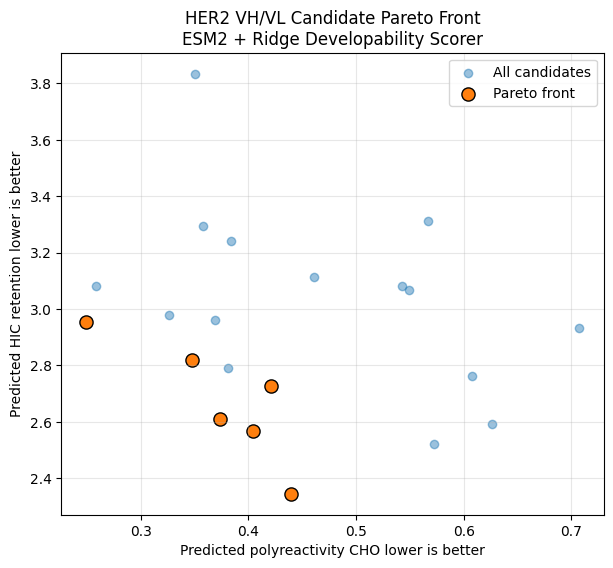

In [ ]:
# -----------------------------
# 7. 2D Pareto plot:
#    polyreactivity vs HIC,
#    color/size represents AC-SINS
# -----------------------------

x = "pred_polyreactivity_cho"
y = "pred_hic_retention"
c = "pred_acsins_pH7p4"

plt.figure(figsize=(7, 6))

plt.scatter(
    cand_df[x],
    cand_df[y],
    alpha=0.45,
    label="All candidates"
)

plt.scatter(
    pareto_df[x],
    pareto_df[y],
    s=90,
    edgecolors="black",
    label="Pareto front"
)

plt.xlabel("Predicted polyreactivity CHO lower is better")
plt.ylabel("Predicted HIC retention lower is better")
plt.title("HER2 VH/VL Candidate Pareto Front\nESM2 + Ridge Developability Scorer")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# -----------------------------
# 9. Save Pareto candidates
# -----------------------------

PARETO_OUT = os.path.join(OUT_DIR, "her2_vh_vl_pareto_candidates.csv")

pareto_df.to_csv(PARETO_OUT, index=False)

print("Saved Pareto candidates:", PARETO_OUT)
print("Top Pareto candidates:")

pareto_df[
    [
        "backbone_id",
        "design_id",
        "developability_score",
        "pred_polyreactivity_cho",
        "pred_hic_retention",
        "pred_acsins_pH7p4",
        "vh_sequence",
        "vl_sequence",
    ]
].head(10)

Saved Pareto candidates: /content/drive/MyDrive/gdpa1_simple_benchmark/her2_vh_vl_pareto_candidates.csv
Top Pareto candidates:


,backbone_id,design_id,developability_score,pred_polyreactivity_cho,pred_hic_retention,pred_acsins_pH7p4,vh_sequence,vl_sequence
0,her2_vh_vl_complex,her2_vh_vl_complex_seq18,2.879270,0.347646,2.820577,-52.139793,AVTLTETPSSLEVKEGDSVTVTCTASQDVSGGWQWYKQKPGGPLEL...,GVSLTFSGAGTIAPGASFTLTCTVSGVDFLQYDVAWVMQKPGGPLQ...
1,her2_vh_vl_complex,her2_vh_vl_complex_seq17,2.410072,0.249263,2.954475,-44.900520,SVTLTETPSSTSATLGDSLTVTCTASSDVSGDVQWYKQLPGGPLQL...,GVSLSFSGGGVIKPGESTTFTCTVSGVDFLTYRVAWVRQLPGGPLQ...
2,her2_vh_vl_complex,her2_vh_vl_complex_seq10,2.231810,0.404525,2.565521,-44.089653,SVTLTETPSALEATDGETVTITCTASEDVSGQVQWYRQKPGGPLEL...,SLTLTVSGAGVIKSGESFTLTCTVSGVDFLQYKVAWVTQKPGGPLQ...
3,her2_vh_vl_complex,her2_vh_vl_complex_seq6,1.921078,0.421048,2.727949,-46.666428,AVTITMTPSSTAVEEGTSLTVTCTASKDVSGDVQWYKQKPGGPLTA...,GVSLTVSGGGTIAPGASTTLTCTVSGVDFLQYRVGWVRQKPGGPLE...
4,her2_vh_vl_complex,her2_vh_vl_complex_seq3,1.649285,0.373902,2.610265,-38.224335,SVKLTMTPSETEAEEGTSLTVTCTASAPVSGSVQWYRQKPGGPFEL...,SLSLTVSGGGVIKPGDSFTLTCTVSGVDFLQYNVAWVRQKPGGPFQ...
7,her2_vh_vl_complex,her2_vh_vl_complex_seq7,1.180989,0.439339,2.344879,-32.006386,KVTLTETPASLEVEEGTSVTITCTASQPVSGDVAWYKQAPGGPLEA...,GVSLTVSGAGTIKAGASTTLTCSVSGLDFLQYRVAWVRQAPGGPLE...


In [ ]:
# =========================
# 0. Colab setup
# =========================
!nvidia-smi

%cd /content
!git clone https://github.com/RosettaCommons/RFdiffusion.git
%cd /content/RFdiffusion

# Install RFdiffusion dependencies
!pip install -q torch==2.2.0+cu118 torchvision==0.17.0+cu118 torchaudio==2.2.0+cu118 \
  --index-url https://download.pytorch.org/whl/cu118
!pip install -q hydra-core pyrsistent icecream einops omegaconf biopython

# Download model weights
!mkdir -p models
%cd models
!wget -q https://files.ipd.uw.edu/pub/RFdiffusion/6f5902ac237024bdd0c176cb93063dc4/Base_ckpt.pt
!wget -q https://files.ipd.uw.edu/pub/RFdiffusion/6f5902ac237024bdd0c176cb93063dc4/Complex_base_ckpt.pt
%cd /content/RFdiffusion

# =========================
# 1. Download HER2-trastuzumab structure
# PDB 1N8Z:
#   chain C = HER2 extracellular domain
#   chain A/B = trastuzumab Fab
# =========================
!mkdir -p /content/her2_project/input
!wget -q https://files.rcsb.org/download/1N8Z.pdb -O /content/her2_project/input/1N8Z.pdb

Wed Apr 29 02:13:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   28C    P0             45W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# =========================
# 2. Optional: extract only HER2 chain C
# RFdiffusion can use the full target PDB,
# but a cropped/clean target is usually faster.
# =========================
from Bio.PDB import PDBParser, PDBIO, Select

class ChainSelect(Select):
    def __init__(self, chain_id):
        self.chain_id = chain_id
    def accept_chain(self, chain):
        return chain.id == self.chain_id

parser = PDBParser(QUIET=True)
structure = parser.get_structure("1N8Z", "/content/her2_project/input/1N8Z.pdb")

io = PDBIO()
io.set_structure(structure)
io.save(
    "/content/her2_project/input/HER2_chainC.pdb",
    ChainSelect("C")
)

print("Saved HER2 target:", "/content/her2_project/input/HER2_chainC.pdb")

Saved HER2 target: /content/her2_project/input/HER2_chainC.pdb


In [ ]:
%cd /content

# Clean conflicting packages
!pip uninstall -y numpy torch torchvision torchaudio

# RFdiffusion is old; keep NumPy 1.x
!pip install -q "numpy<2" "torch==2.2.0+cu118" "torchvision==0.17.0+cu118" "torchaudio==2.2.0+cu118" \
  --index-url https://download.pytorch.org/whl/cu118

# Install RFdiffusion dependencies
!pip install -q hydra-core pyrsistent icecream einops omegaconf biopython scipy pandas
import numpy as np, torch
print("numpy:", np.__version__)
print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())

/content
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: torch 2.2.0+cu118
Uninstalling torch-2.2.0+cu118:
  Successfully uninstalled torch-2.2.0+cu118
Found existing installation: torchvision 0.17.0+cu118
Uninstalling torchvision-0.17.0+cu118:
  Successfully uninstalled torchvision-0.17.0+cu118
Found existing installation: torchaudio 2.2.0+cu118
Uninstalling torchaudio-2.2.0+cu118:
  Successfully uninstalled torchaudio-2.2.0+cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 19.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which 

In [ ]:
%cd /content/RFdiffusion

!pip install -q dgl -f https://data.dgl.ai/wheels/torch-2.2/cu118/repo.html

/content/RFdiffusion
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.1/529.1 MB 2.2 MB/s eta 0:00:00


In [ ]:
%cd /content/RFdiffusion

# Pull submodules, including SE3Transformer
!git submodule update --init --recursive

# Install the bundled SE3 transformer package
%cd /content/RFdiffusion/env/SE3Transformer
!pip install -q .

# Go back to RFdiffusion
%cd /content/RFdiffusion

import se3_transformer
print("SE3 transformer import OK")

/content/RFdiffusion
/content/RFdiffusion/env/SE3Transformer
  Preparing metadata (setup.py) ... done
/content/RFdiffusion
SE3 transformer import OK


In [ ]:
%cd /content/RFdiffusion

!pip install -q e3nn==0.3.3 opt_einsum

%cd /content/RFdiffusion/env/SE3Transformer
!pip install -q .

%cd /content/RFdiffusion

/content/RFdiffusion
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 382.1/382.1 kB 13.2 MB/s eta 0:00:00
/content/RFdiffusion/env/SE3Transformer
  Preparing metadata (setup.py) ... done
/content/RFdiffusion


In [ ]:
%cd /content/RFdiffusion

!mkdir -p models
!wget -O models/Complex_base_ckpt.pt \
  https://files.ipd.uw.edu/pub/RFdiffusion/6f5902ac237024bdd0c176cb93063dc4/Complex_base_ckpt.pt

!ls -lh models/

/content/RFdiffusion
--2026-04-29 02:17:01--  https://files.ipd.uw.edu/pub/RFdiffusion/6f5902ac237024bdd0c176cb93063dc4/Complex_base_ckpt.pt
Resolving files.ipd.uw.edu (files.ipd.uw.edu)... 128.95.160.134, 128.95.160.135, 2607:4000:406::160:134, ...
Connecting to files.ipd.uw.edu (files.ipd.uw.edu)|128.95.160.134|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-04-29 02:17:01 ERROR 404: Not Found.

total 462M
-rw-r--r-- 1 root root 462M Mar 30  2023 Base_ckpt.pt
-rw-r--r-- 1 root root    0 Apr 29 02:17 Complex_base_ckpt.pt


In [ ]:
%cd /content/RFdiffusion

!mkdir -p models
!rm -f models/Complex_base_ckpt.pt

!wget -O models/Complex_base_ckpt.pt \
  http://files.ipd.uw.edu/pub/RFdiffusion/e29311f6f1bf1af907f9ef9f44b8328b/Complex_base_ckpt.pt

!ls -lh models/Complex_base_ckpt.pt

/content/RFdiffusion
--2026-04-29 02:17:01--  http://files.ipd.uw.edu/pub/RFdiffusion/e29311f6f1bf1af907f9ef9f44b8328b/Complex_base_ckpt.pt
Resolving files.ipd.uw.edu (files.ipd.uw.edu)... 128.95.160.134, 128.95.160.135, 2607:4000:406::160:134, ...
Connecting to files.ipd.uw.edu (files.ipd.uw.edu)|128.95.160.134|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 483619179 (461M) [application/octet-stream]
Saving to: ‘models/Complex_base_ckpt.pt’

models/Complex_base 100%[===================>] 461.21M  32.6MB/s    in 10s     

2026-04-29 02:17:12 (46.2 MB/s) - ‘models/Complex_base_ckpt.pt’ saved [483619179/483619179]

-rw-r--r-- 1 root root 462M Mar 30  2023 models/Complex_base_ckpt.pt


In [ ]:
!grep "^ATOM" /content/her2_project/input/HER2_chainC.pdb \
| awk '{print substr($0,22,1), substr($0,23,4)}' \
| sort -k2n | uniq \
| awk '$1=="C"{print $2}' \
| awk 'NR==1{s=p=$1; next} $1==p+1{p=$1; next} {print s"-"p; s=p=$1} END{print s"-"p}'

1-101
111-302
306-360
365-580
591-607


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =========================
# 3. Choose hotspot residues
# =========================
# For an MVP, use HER2 domain IV / trastuzumab epitope-area residues.
# IMPORTANT: verify these in PyMOL/ChimeraX before final runs.
#
# Replace with your chosen HER2 chain C residues.
# Format expected by RFdiffusion: [C557,C558,C561]
#
hotspots = "[C557,C558,C561,C570,C593]"
print(hotspots)

# =========================
# 4. Run RFdiffusion binder design
# =========================
# This designs de novo binders of length 80-120 aa to HER2 chain C.
# Target chain C is fixed; new binder is generated after /0.
# num_designs=10 for MVP; increase to 100 later.
# =========================

%cd /content/RFdiffusion

# set output folder ON DRIVE
OUT_DIR = "/content/drive/MyDrive/her2_project/rfdiffusion_outputs"
INPUT_PDB = "/content/her2_project/input/HER2_chainC.pdb"

!mkdir -p {OUT_DIR}

!DGLBACKEND=pytorch PYTHONPATH=/content/RFdiffusion python scripts/run_inference.py \
  inference.output_prefix={OUT_DIR}/her2_binder \
  inference.input_pdb={INPUT_PDB} \
  inference.num_designs=50 \
  'contigmap.contigs=[C1-101/C111-302/C306-360/C365-580/C591-607/0 80-120]' \
  'ppi.hotspot_res=[C557,C558,C561,C570,C593]' \
  denoiser.noise_scale_ca=0 \
  denoiser.noise_scale_frame=0

[C557,C558,C561,C570,C593]
/content/RFdiffusion
/content/RFdiffusion/scripts/run_inference.py:63: SyntaxWarning: invalid escape sequence '\d'
  m = re.match(".*_(\d+)\.pdb$", e)
/content/RFdiffusion/rfdiffusion/util.py:253: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at ../aten/src/ATen/native/Cross.cpp:63.)
  Z = torch.cross(Xn, Yn)
/content/RFdiffusion/rfdiffusion/diffusion.py:267: SyntaxWarning: invalid escape sequence '\s'
  Extract \sigma(t) corresponding to chosen sigma schedule.
/content/RFdiffusion/rfdiffusion/diffusion.py:294: SyntaxWarning: invalid escape sequence '\i'
  sigma(t)^2 := \int_0^t g(s)^2 ds,
[2026-04-29 02:18:52,840][__main__][INFO] - Found GPU with device_name NVIDIA A100-SXM4-40GB. Will run RFdiffusion on NVIDIA A100-SXM4-40GB
Reading models fro

In [ ]:
import glob

pdbs = glob.glob(f"{OUT_DIR}/**/*.pdb", recursive=True)

print("Saved RFdiffusion PDBs:", len(pdbs))
print(pdbs[:5])

In [ ]:
# =========================
# 0. Install basics
# =========================
!pip install -q biopython pandas numpy tqdm transformers accelerate scikit-learn joblib
# =========================
# 1. Clone ProteinMPNN
# =========================
%cd /content
!rm -rf ProteinMPNN
!git clone https://github.com/dauparas/ProteinMPNN.git
%cd /content/ProteinMPNN

# =========================
# 2. Locate RFdiffusion PDBs
# =========================
import glob, os

PROJECT_DIR = "/content/her2_project"
RFDIFF_DIR = f"{PROJECT_DIR}/rfdiffusion_outputs"
MPNN_OUT = f"{PROJECT_DIR}/proteinmpnn_outputs"

os.makedirs(MPNN_OUT, exist_ok=True)

pdbs = sorted(glob.glob(f"{RFDIFF_DIR}/*.pdb"))
print("RFdiffusion PDBs:", len(pdbs))
print(pdbs[:5])

# =========================
# 3. Make ProteinMPNN input folder
# =========================
import shutil

MPNN_INPUT = f"{PROJECT_DIR}/proteinmpnn_inputs"
os.makedirs(MPNN_INPUT, exist_ok=True)

for pdb in pdbs:
    shutil.copy(pdb, MPNN_INPUT)

print("Copied PDBs:", len(glob.glob(f'{MPNN_INPUT}/*.pdb')))

/content
Cloning into 'ProteinMPNN'...
remote: Enumerating objects: 634, done.
remote: Counting objects: 100% (271/271), done.
remote: Compressing objects: 100% (125/125), done.
remote: Total 634 (delta 151), reused 146 (delta 146), pack-reused 363 (from 1)
Receiving objects: 100% (634/634), 119.90 MiB | 22.45 MiB/s, done.
Resolving deltas: 100% (290/290), done.
/content/ProteinMPNN
RFdiffusion PDBs: 1
['/content/her2_project/rfdiffusion_outputs/her2_binder_0.pdb']
Copied PDBs: 1


In [ ]:
# =========================
# 4. Parse PDBs for ProteinMPNN
# =========================
%cd /content/ProteinMPNN

!python helper_scripts/parse_multiple_chains.py \
  --input_path /content/her2_project/proteinmpnn_inputs \
  --output_path /content/her2_project/parsed_pdbs.jsonl

  # =========================
# 5. Assign fixed/designed chains
# Usually:
#   HER2 target = chain C, fixed
#   RFdiffusion binder = chain D or last chain, designed
#
# First inspect chains manually from one output.
# =========================
!head -n 1 /content/her2_project/parsed_pdbs.jsonl

TARGET_CHAIN = "C"
BINDER_CHAIN = "D"   # change if your binder chain is different

print("Fixed target:", TARGET_CHAIN)
print("Designed binder:", BINDER_CHAIN)

import json

with open("/content/her2_project/parsed_pdbs.jsonl") as f:
    first = json.loads(f.readline())

chain_keys = [k for k in first.keys() if k.startswith("seq_chain_")]
print(chain_keys)

chains = [k.replace("seq_chain_", "") for k in chain_keys]
print("Available chains:", chains)

TARGET_CHAIN = "C"
BINDER_CHAIN = [c for c in chains if c != TARGET_CHAIN][-1]

print("Target chain:", TARGET_CHAIN)
print("Binder chain:", BINDER_CHAIN)


%cd /content/ProteinMPNN

!python helper_scripts/assign_fixed_chains.py \
  --input_path /content/her2_project/parsed_pdbs.jsonl \
  --output_path /content/her2_project/assigned_pdbs.jsonl \
  --chain_list "$BINDER_CHAIN"

/content/ProteinMPNN
{"seq_chain_A": "GGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG", "coords_chain_A": {"N_chain_A": [[22.904, -1.447, -32.812], [24.364, -0.797, -30.569], [24.96, -3.389, -29.767], [26.669, -4.24, -31.838], [28.751, -2.473, -31.357], [29.568, -3.346, -28.816], [30.34, -5.96, -29.438], [32.557, -5.442, -31.065], [34.164, -4.175, -29.207], [34.656, -6.295, -27.455], [36.091, -8.017, -29.141], [38.309, -6.392, -29.495], [39.347, -6.334, -26.891], [39.965, -9.014, -26.62], [41.953, -9.307, -28.553], [43.794, -7.604, -27.458], [44.412, -8.95, -25.083], [45.602, -11.227, -26.177], [47.803, -10.03, -27.321], [49.18, -9.168, -25.054], [49.79, -11.614, -23.994], [51.478, -12.617, -25.942], [53.531, -10.819, -25.743], [54.459, -11.325, -23.147], [55.348, -13.931, -23.569], [57.34, -13.379, -25.384], [59.168, -11.967, -23.832], [59.826, -13.945, -22.044], [61.076, -15.768, -23.726], [63.226, -14.28, -24.614], [64.667, -14.0, -22.258], [65.26

In [ ]:
# =========================
# 7. Run ProteinMPNN
# Generate 8 sequences per backbone
# Increase to 16 later
# =========================
%cd /content/ProteinMPNN

!python protein_mpnn_run.py \
  --jsonl_path /content/her2_project/parsed_pdbs.jsonl \
  --chain_id_jsonl /content/her2_project/assigned_pdbs.jsonl \
  --out_folder /content/her2_project/proteinmpnn_outputs \
  --num_seq_per_target 8 \
  --sampling_temp "0.1" \
  --seed 42 \
  --batch_size 1

/content/ProteinMPNN
----------------------------------------
fixed_positions_jsonl is NOT loaded
----------------------------------------
pssm_jsonl is NOT loaded
----------------------------------------
omit_AA_jsonl is NOT loaded
----------------------------------------
bias_AA_jsonl is NOT loaded
----------------------------------------
tied_positions_jsonl is NOT loaded
----------------------------------------
bias by residue dictionary is not loaded, or not provided
----------------------------------------
discarded {'bad_chars': 0, 'too_long': 0, 'bad_seq_length': 0}
----------------------------------------
Number of edges: 48
Training noise level: 0.2A
Generating sequences for: her2_binder_0
8 sequences of length 690 generated in 20.234 seconds


In [ ]:
# ============================================================
# 0. Install packages
# ============================================================

!pip -q install \
  numpy pandas scipy scikit-learn tqdm joblib biopython \
  transformers accelerate sentencepiece safetensors huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 109.7 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 1. Mount Drive and set paths
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import os, random, warnings, glob, joblib
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

BASE = "/content/drive/MyDrive/her2_ab_mvp"
OUT_DIR = "/content/drive/MyDrive/gdpa1_simple_benchmark"
EMBED_DIR = os.path.join(OUT_DIR, "embeddings")
MODEL_DIR = os.path.join(OUT_DIR, "final_esm2_ridge_models")

for d in [BASE, OUT_DIR, EMBED_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

Mounted at /content/drive
DEVICE: cuda


In [ ]:
# ============================================================
# 2. Load GDPa1 developability dataset
# ============================================================

CSV_PATH = "/content/drive/MyDrive/MIT_comp_sysbio_proj/gdpa1_cleaned.csv"

ID_COL = "antibody_id"
VH_COL = "vh_sequence"
VL_COL = "vl_sequence"
FOLD_COL = "fold_hc_cluster"

TARGET_COLS = [
    "titer_cho",
    "sec_monomer_pct",
    "hic_retention",
    "acsins_pH6",
    "acsins_pH7p4",
    "polyreactivity_cho",
    "polyreactivity_ova",
]

FINAL_TARGETS = [
    "polyreactivity_cho",
    "hic_retention",
    "acsins_pH7p4",
]

df = pd.read_csv(CSV_PATH)
print(df.shape)
df.head()

(246, 12)


,antibody_id,vh_sequence,vl_sequence,titer_cho,sec_monomer_pct,hic_retention,acsins_pH6,acsins_pH7p4,polyreactivity_cho,polyreactivity_ova,fold_hc_cluster,fold_hc_cluster_isotype_stratified
0,GDPa1-001,QVKLQESGAELARPGASVKLSCKASGYTFTNYWMQWVKQRPGQGLD...,DIELTQSPASLSASVGETVTITCQASENIYSYLAWHQQKQGKSPQL...,140.25,97.010,2.590,0.35,2.125,0.337837,0.263108,1,2
1,GDPa1-002,QVQLQQSGGELAKPGASVKVSCKASGYTFSSFWMHWVRQAPGQGLE...,DIQMTQSPSSLSASVGDRVTITCRASQDISNYLAWYQQKPGKAPKL...,193.31,97.620,2.545,1.10,1.500,0.205246,0.100155,1,0
2,GDPa1-003,QVTLKESGPVLVKPTETLTLTCTVSGFSLTNYHVQWIRQPPGKALE...,DIQMTQSPSSLSASVGDRVTITCLASEDISNYLAWYQQKPGKAPKL...,114.75,89.055,2.705,0.75,1.000,0.138773,0.101180,2,2
3,GDPa1-004,QVQLVQSGAEVKKPGASVKVSCKVSGYTLSDLSIHWVRQAPGKGLE...,DIQMTQSPSSVSASVGDRVTITCRASQGISSWLAWYQQKPGKAPKL...,327.32,98.605,2.565,0.46,-0.375,0.000000,0.054971,1,0
4,GDPa1-005,EVQLVESGGGLVQPGRSLRLSCAASGFTFDDYAMHWVRQAPGKGLE...,DIQMTQSPSSLSASVGDRVTITCRASQGIRNYLAWYQQKPGKAPKL...,313.39,96.120,2.495,0.61,7.500,0.183387,0.085628,0,0


In [ ]:
# ============================================================
# 3. Clean sequences
# ============================================================

AA_ORDER = list("ACDEFGHIKLMNPQRSTVWY")
AA_SET = set(AA_ORDER)

def clean_seq(seq):
    if pd.isna(seq):
        return ""
    seq = str(seq).strip().upper()
    return "".join([aa for aa in seq if aa in AA_SET])

def make_pair_sequence(vh, vl, sep_token="X"):
    return f"{clean_seq(vh)}{sep_token}{clean_seq(vl)}"

df[VH_COL] = df[VH_COL].map(clean_seq)
df[VL_COL] = df[VL_COL].map(clean_seq)

df = df[
    (df[VH_COL].str.len() > 0) &
    (df[VL_COL].str.len() > 0) &
    (df[FOLD_COL].notna())
].reset_index(drop=True)

print("Filtered:", df.shape)
print("Folds:", sorted(df[FOLD_COL].unique()))

Filtered: (246, 12)
Folds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [ ]:
# ============================================================
# 4. Embed GDPa1 sequences with ESM-2
# ============================================================

from transformers import AutoTokenizer, AutoModel

ESM2_MODEL_NAME = "facebook/esm2_t33_650M_UR50D"

@torch.no_grad()
def embed_with_esm2_hf(sequences, model_name=ESM2_MODEL_NAME, batch_size=4, max_length=1022):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.to(DEVICE).eval()

    outputs = []

    for i in tqdm(range(0, len(sequences), batch_size), desc="ESM-2 embedding"):
        batch = sequences[i:i+batch_size]

        toks = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length,
        )

        toks = {k: v.to(DEVICE) for k, v in toks.items()}
        out = model(**toks)

        hidden = out.last_hidden_state
        mask = toks["attention_mask"].unsqueeze(-1).float()

        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
        outputs.append(pooled.detach().cpu().numpy())

    return np.vstack(outputs).astype(np.float32)


def get_or_compute_esm2(df_in, cache_path):
    if os.path.exists(cache_path):
        X = np.load(cache_path)["X"]
        if len(X) == len(df_in):
            print("Loaded:", cache_path)
            return X

    seqs = [
        make_pair_sequence(vh, vl)
        for vh, vl in zip(df_in[VH_COL], df_in[VL_COL])
    ]

    X = embed_with_esm2_hf(seqs)
    np.savez_compressed(cache_path, X=X)
    print("Saved:", cache_path)

    return X


X_esm2 = get_or_compute_esm2(
    df,
    os.path.join(EMBED_DIR, "gdpa1_esm2_pair.npz")
)

print(X_esm2.shape)

config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ESM-2 embedding:   0%|          | 0/62 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/gdpa1_simple_benchmark/embeddings/gdpa1_esm2_pair.npz
(246, 1280)


In [ ]:
# ============================================================
# 5. Train final ESM2 + Ridge developability models
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

final_models = {}

for target in FINAL_TARGETS:
    keep = df[target].notna().values

    X_train = X_esm2[keep]
    y_train = df.loc[keep, target].values.astype(np.float32)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0)),
    ])

    model.fit(X_train, y_train)

    model_path = os.path.join(MODEL_DIR, f"esm2_ridge_{target}.joblib")
    joblib.dump(model, model_path)

    final_models[target] = model

    print(f"Saved {target}: {model_path}")

Saved polyreactivity_cho: /content/drive/MyDrive/gdpa1_simple_benchmark/final_esm2_ridge_models/esm2_ridge_polyreactivity_cho.joblib
Saved hic_retention: /content/drive/MyDrive/gdpa1_simple_benchmark/final_esm2_ridge_models/esm2_ridge_hic_retention.joblib
Saved acsins_pH7p4: /content/drive/MyDrive/gdpa1_simple_benchmark/final_esm2_ridge_models/esm2_ridge_acsins_pH7p4.joblib


In [ ]:
# ============================================================
# 6. Clone ProteinMPNN and prepare HER2 complex
# ============================================================

%cd /content

!git clone https://github.com/dauparas/ProteinMPNN.git || true
!pip -q install biopython pandas numpy

INPUT_DIR = f"{BASE}/input_pdbs"
MPNN_INPUT_DIR = f"{BASE}/mpnn_input"
PARSED_DIR = f"{BASE}/mpnn_parsed"
MPNN_OUT = f"{BASE}/mpnn_out"

for d in [INPUT_DIR, MPNN_INPUT_DIR, PARSED_DIR, MPNN_OUT]:
    os.makedirs(d, exist_ok=True)

%cd {INPUT_DIR}

# HER2-antibody complex example
!wget -q https://files.rcsb.org/download/6OGE.pdb -O her2_antibody_complex.pdb

PDB_PATH = f"{INPUT_DIR}/her2_antibody_complex.pdb"
print(PDB_PATH)

/content
Cloning into 'ProteinMPNN'...
remote: Enumerating objects: 634, done.
remote: Counting objects: 100% (256/256), done.
remote: Compressing objects: 100% (124/124), done.
remote: Total 634 (delta 137), reused 132 (delta 132), pack-reused 378 (from 1)
Receiving objects: 100% (634/634), 119.90 MiB | 15.42 MiB/s, done.
Resolving deltas: 100% (290/290), done.
/content/drive/MyDrive/her2_ab_mvp/input_pdbs
/content/drive/MyDrive/her2_ab_mvp/input_pdbs/her2_antibody_complex.pdb


In [ ]:
# ============================================================
# 7. Inspect chains and save HER2 + VH + VL complex
# ============================================================

from Bio.PDB import PDBParser, PDBIO, Select

parser = PDBParser(QUIET=True)
structure = parser.get_structure("her2_ab", PDB_PATH)

for chain in structure[0]:
    residues = [r for r in chain if r.id[0] == " "]
    if len(residues) > 0:
        print(
            "Chain:", chain.id,
            "n_res:", len(residues),
            "start:", residues[0].id[1],
            "end:", residues[-1].id[1],
        )

HER2_CHAIN = "A"
VH_CHAIN = "B"
VL_CHAIN = "C"

class KeepChains(Select):
    def accept_chain(self, chain):
        return chain.id in [HER2_CHAIN, VH_CHAIN, VL_CHAIN]

out_pdb = f"{MPNN_INPUT_DIR}/her2_vh_vl_complex.pdb"

io = PDBIO()
io.set_structure(structure)
io.save(out_pdb, KeepChains())

print("Saved:", out_pdb)

Chain: A n_res: 619 start: 23 end: 644
Chain: B n_res: 214 start: 1 end: 214
Chain: C n_res: 222 start: 1 end: 216
Chain: D n_res: 214 start: 1 end: 214
Chain: E n_res: 220 start: 1 end: 220
Saved: /content/drive/MyDrive/her2_ab_mvp/mpnn_input/her2_vh_vl_complex.pdb
MPNN_OUT: /content/drive/MyDrive/her2_ab_mvp/mpnn_out

DIR: /content/drive/MyDrive/her2_ab_mvp/mpnn_out


In [ ]:
# ============================================================
# 8. Run ProteinMPNN
# ============================================================

%cd /content/ProteinMPNN

!python helper_scripts/parse_multiple_chains.py \
  --input_path {MPNN_INPUT_DIR} \
  --output_path {PARSED_DIR}/parsed.jsonl

DESIGN_CHAINS = f"{VH_CHAIN} {VL_CHAIN}"

!python helper_scripts/assign_fixed_chains.py \
  --input_path {PARSED_DIR}/parsed.jsonl \
  --output_path {PARSED_DIR}/assigned.jsonl \
  --chain_list "{DESIGN_CHAINS}"

!python protein_mpnn_run.py \
  --jsonl_path {PARSED_DIR}/parsed.jsonl \
  --chain_id_jsonl {PARSED_DIR}/assigned.jsonl \
  --out_folder {MPNN_OUT} \
  --num_seq_per_target 50 \
  --sampling_temp "0.1" \
  --seed 42 \
  --batch_size 1

/content/ProteinMPNN
----------------------------------------
fixed_positions_jsonl is NOT loaded
----------------------------------------
pssm_jsonl is NOT loaded
----------------------------------------
omit_AA_jsonl is NOT loaded
----------------------------------------
bias_AA_jsonl is NOT loaded
----------------------------------------
tied_positions_jsonl is NOT loaded
----------------------------------------
bias by residue dictionary is not loaded, or not provided
----------------------------------------
discarded {'bad_chars': 0, 'too_long': 0, 'bad_seq_length': 0}
----------------------------------------
Number of edges: 48
Training noise level: 0.2A
Generating sequences for: her2_vh_vl_complex
50 sequences of length 1058 generated in 232.268 seconds


In [ ]:
# ============================================================
# 9. Parse ProteinMPNN FASTA outputs
# ============================================================

MPNN_SEQ_DIR = f"{MPNN_OUT}/seqs"
CANDIDATE_CSV = f"{BASE}/her2_vh_vl_candidates.csv"

def read_fasta(path):
    records = []
    header = None
    seq_lines = []

    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            if line.startswith(">"):
                if header is not None:
                    records.append((header, "".join(seq_lines)))
                header = line[1:]
                seq_lines = []
            else:
                seq_lines.append(line)

    if header is not None:
        records.append((header, "".join(seq_lines)))

    return records


rows = []

for fa in glob.glob(f"{MPNN_SEQ_DIR}/*.fa"):
    backbone_id = os.path.basename(fa).replace(".fa", "")
    records = read_fasta(fa)

    for i, (header, seq) in enumerate(records):
        chains = seq.split("/")

        # Expected order: HER2 / VH / VL
        if len(chains) >= 3:
            vh_seq = chains[1]
            vl_seq = chains[2]
        elif len(chains) == 2:
            vh_seq = chains[0]
            vl_seq = chains[1]
        else:
            continue

        rows.append({
            "backbone_id": backbone_id,
            "design_id": f"{backbone_id}_seq{i}",
            "vh_sequence": clean_seq(vh_seq),
            "vl_sequence": clean_seq(vl_seq),
            "raw_header": header,
            "raw_sequence": seq,
        })

cand_df = pd.DataFrame(rows)
cand_df = cand_df[
    (cand_df["vh_sequence"].str.len() > 0) &
    (cand_df["vl_sequence"].str.len() > 0)
].reset_index(drop=True)

cand_df.to_csv(CANDIDATE_CSV, index=False)

print("Saved:", CANDIDATE_CSV)
print(cand_df.shape)
cand_df.head()

Saved: /content/drive/MyDrive/her2_ab_mvp/her2_vh_vl_candidates.csv
(51, 6)


,backbone_id,design_id,vh_sequence,vl_sequence,raw_header,raw_sequence
0,her2_vh_vl_complex,her2_vh_vl_complex_seq0,DIQMTQSPSSLSASVGDRVTITCKASQDVSIGVAWYQQKPGKAPKL...,EVQLVESGGGLVQPGGSLRLSCAASGFTFTDYTMDWVRQAPGKGLE...,"her2_vh_vl_complex, score=1.7513, global_score...",DIQMTQSPSSLSASVGDRVTITCKASQDVSIGVAWYQQKPGKAPKL...
1,her2_vh_vl_complex,her2_vh_vl_complex_seq1,SVTLTETPTSLSVTEGTSVTITCTASSDVSSGVQWYAQKPGGPLQL...,PLSLTVSGGGTIAAGASTTLTCTVSGVDFLQYRVAWVAQKPGGPLK...,"T=0.1, sample=1, score=0.9899, global_score=1....",SVTLTETPTSLSVTEGTSVTITCTASSDVSSGVQWYAQKPGGPLQL...
2,her2_vh_vl_complex,her2_vh_vl_complex_seq2,SVTITETPASLSVTEGDSVTITCTFSSDVSGKVAWYRQKPGGPFEA...,SLTLTVSGAGVIPPGASTTLTCTVSGVDFLQYKVAWVAQKPGGPFQ...,"T=0.1, sample=2, score=0.9777, global_score=1....",SVTITETPASLSVTEGDSVTITCTFSSDVSGKVAWYRQKPGGPFEA...
3,her2_vh_vl_complex,her2_vh_vl_complex_seq3,SVKLTMTPSETEAEEGTSLTVTCTASAPVSGSVQWYRQKPGGPFEL...,SLSLTVSGGGVIKPGDSFTLTCTVSGVDFLQYNVAWVRQKPGGPFQ...,"T=0.1, sample=3, score=1.0316, global_score=1....",SVKLTMTPSETEAEEGTSLTVTCTASAPVSGSVQWYRQKPGGPFEL...
4,her2_vh_vl_complex,her2_vh_vl_complex_seq4,SVTLTETPSSTSVKEGDSVTVTCTASEPVSGDWQWYMQKPGGPLQL...,GVSLTQSGAGTIAPGASTTLTCTVSGVDFLQYNVAWVRQKPGGPLE...,"T=0.1, sample=4, score=1.0117, global_score=1....",SVTLTETPSSTSVKEGDSVTVTCTASEPVSGDWQWYMQKPGGPLQL...


In [ ]:
# ============================================================
# 10. Embed HER2 candidates with ESM-2
# ============================================================

cand_for_embed = cand_df.rename(columns={
    "vh_sequence": VH_COL,
    "vl_sequence": VL_COL,
})

CAND_EMBED_PATH = os.path.join(EMBED_DIR, "her2_vh_vl_candidates_esm2.npz")

X_cand_esm2 = get_or_compute_esm2(
    cand_for_embed,
    CAND_EMBED_PATH,
)

print("Candidate ESM2 shape:", X_cand_esm2.shape)

# ============================================================
# 11. Predict developability liabilities
# ============================================================

for target in FINAL_TARGETS:
    cand_df[f"pred_{target}"] = final_models[target].predict(X_cand_esm2)

cand_df[
    ["backbone_id", "design_id"] +
    [f"pred_{t}" for t in FINAL_TARGETS]
].head()

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ESM-2 embedding:   0%|          | 0/13 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/gdpa1_simple_benchmark/embeddings/her2_vh_vl_candidates_esm2.npz
Candidate ESM2 shape: (51, 1280)


,backbone_id,design_id,pred_polyreactivity_cho,pred_hic_retention,pred_acsins_pH7p4
0,her2_vh_vl_complex,her2_vh_vl_complex_seq0,0.548932,3.068621,-24.855873
1,her2_vh_vl_complex,her2_vh_vl_complex_seq1,0.461076,3.114881,-34.125675
2,her2_vh_vl_complex,her2_vh_vl_complex_seq2,0.350757,3.833964,-38.899445
3,her2_vh_vl_complex,her2_vh_vl_complex_seq3,0.373885,2.610294,-38.226898
4,her2_vh_vl_complex,her2_vh_vl_complex_seq4,0.381242,2.791887,-22.742514


In [ ]:
# ============================================================
# 12. Compute composite developability score
# ============================================================

# Assumption:
# lower polyreactivity, lower HIC retention, and lower AC-SINS are better.
# Therefore higher composite score is better.

for target in FINAL_TARGETS:
    col = f"pred_{target}"
    cand_df[f"z_{target}"] = (
        cand_df[col] - cand_df[col].mean()
    ) / cand_df[col].std()

cand_df["developability_score"] = -(
    cand_df["z_polyreactivity_cho"] +
    cand_df["z_hic_retention"] +
    cand_df["z_acsins_pH7p4"]
)

cand_df = cand_df.sort_values(
    "developability_score",
    ascending=False
).reset_index(drop=True)

cand_df.head(10)

,backbone_id,design_id,vh_sequence,vl_sequence,raw_header,raw_sequence,pred_polyreactivity_cho,pred_hic_retention,pred_acsins_pH7p4,z_polyreactivity_cho,z_hic_retention,z_acsins_pH7p4,developability_score
0,her2_vh_vl_complex,her2_vh_vl_complex_seq23,EVTLTETPTSTEVTEGDSVTVTCTASAPVSGNVQWYKQKPGGPLQL...,SLSLTVSGGGTIAAGASTTLTCTVSGVDFLQYRVAWVAQKPGGPLQ...,"T=0.1, sample=23, score=0.9861, global_score=1...",EVTLTETPTSTEVTEGDSVTVTCTASAPVSGNVQWYKQKPGGPLQL...,0.202151,1.948827,-46.673607,-1.860997,-2.707711,-1.205528,5.774236
1,her2_vh_vl_complex,her2_vh_vl_complex_seq18,AVTLTETPSSLEVKEGDSVTVTCTASQDVSGGWQWYKQKPGGPLEL...,GVSLTFSGAGTIAPGASFTLTCTVSGVDFLQYDVAWVMQKPGGPLQ...,"T=0.1, sample=18, score=1.0015, global_score=1...",AVTLTETPSSLEVKEGDSVTVTCTASQDVSGGWQWYKQKPGGPLEL...,0.347627,2.820611,-52.143593,-0.842728,-0.196440,-1.851421,2.890588
2,her2_vh_vl_complex,her2_vh_vl_complex_seq42,KVTITETPSALEVEEGDAVTITCTFSEDVSGKVAWYKQKPGGPLQL...,SLSLSVSGGGVIPPGASTTLTCTVSGVDFNQYRIAWVRQKPGGPLE...,"T=0.1, sample=42, score=0.9864, global_score=1...",KVTITETPSALEVEEGDAVTITCTFSEDVSGKVAWYKQKPGGPLQL...,0.439806,2.178228,-41.712002,-0.197518,-2.046897,-0.619665,2.864079
3,her2_vh_vl_complex,her2_vh_vl_complex_seq25,AVTLTETPTSTSVTLGDSVTVTCTASADVSGGVQWYRQKPGGPFEA...,GPSLTVSGGGTIAAGASTTFTCTVSGLDFLQYEVAWVRQKPGGPFQ...,"T=0.1, sample=25, score=0.9956, global_score=1...",AVTLTETPTSTSVTLGDSVTVTCTASADVSGGVQWYRQKPGGPFEA...,0.381414,2.563267,-43.868866,-0.606239,-0.937749,-0.874346,2.418335
4,her2_vh_vl_complex,her2_vh_vl_complex_seq17,SVTLTETPSSTSATLGDSLTVTCTASSDVSGDVQWYKQLPGGPLQL...,GVSLSFSGGGVIKPGESTTFTCTVSGVDFLTYRVAWVRQLPGGPLQ...,"T=0.1, sample=17, score=0.9981, global_score=1...",SVTLTETPSSTSATLGDSLTVTCTASSDVSGDVQWYKQLPGGPLQL...,0.249252,2.954512,-44.902573,-1.531312,0.189278,-0.996406,2.338440
5,her2_vh_vl_complex,her2_vh_vl_complex_seq10,SVTLTETPSALEATDGETVTITCTASEDVSGQVQWYRQKPGGPLEL...,SLTLTVSGAGVIKSGESFTLTCTVSGVDFLQYKVAWVTQKPGGPLQ...,"T=0.1, sample=10, score=1.0015, global_score=1...",SVTLTETPSALEATDGETVTITCTASEDVSGQVQWYRQKPGGPLEL...,0.404504,2.565541,-44.092766,-0.444617,-0.931198,-0.900784,2.276599
6,her2_vh_vl_complex,her2_vh_vl_complex_seq28,KVTLTETPASTAAEEGTSLTVTCTASEDVSGGVQWYAQKPGGPLEL...,GVSLTVSGGGTIKAGESQTLTCTVSGVDFLQYRVAWVRQKPGGPLE...,"T=0.1, sample=28, score=0.9895, global_score=1...",KVTLTETPASTAAEEGTSLTVTCTASEDVSGGVQWYAQKPGGPLEL...,0.371535,2.615444,-41.386845,-0.675383,-0.787446,-0.581271,2.044100
7,her2_vh_vl_complex,her2_vh_vl_complex_seq6,AVTITMTPSSTAVEEGTSLTVTCTASKDVSGDVQWYKQKPGGPLTA...,GVSLTVSGGGTIAPGASTTLTCTVSGVDFLQYRVGWVRQKPGGPLE...,"T=0.1, sample=6, score=0.9924, global_score=1....",AVTITMTPSSTAVEEGTSLTVTCTASKDVSGDVQWYKQKPGGPLTA...,0.421028,2.727991,-46.669327,-0.328959,-0.463243,-1.205023,1.997225
8,her2_vh_vl_complex,her2_vh_vl_complex_seq38,SVTLTETPSSLEAELGDSVTVTCTLSSDVSSGVQWYKQKPGGPLEL...,GLSLTVSGAGTIAAGASTTLTCTVSGLDFLQYRVAWVLQKPGGPFQ...,"T=0.1, sample=38, score=1.0151, global_score=1...",SVTLTETPSSLEAELGDSVTVTCTLSSDVSSGVQWYKQKPGGPLEL...,0.296602,2.843487,-41.208057,-1.199880,-0.130542,-0.560160,1.890582
9,her2_vh_vl_complex,her2_vh_vl_complex_seq21,SVTWTETPSSTEVTEGDSITITCTASEDVSGGVQWYKQKPGGPLQA...,PVSLTFSGAGTIKPGESTTLTCTVSGLDFLQYRVGWVRQKPGGPFE...,"T=0.1, sample=21, score=1.0124, global_score=1...",SVTWTETPSSTEVTEGDSITITCTASEDVSGGVQWYKQKPGGPLQA...,0.376889,2.757992,-43.693649,-0.637913,-0.376821,-0.853657,1.868391


In [ ]:
# ============================================================
# 13. Pareto front selection
# ============================================================

def get_pareto_front_minimize(values):
    """
    values: array [n_samples, n_objectives]
    True = Pareto-efficient.
    Lower is better for all objectives.
    """
    n = values.shape[0]
    is_pareto = np.ones(n, dtype=bool)

    for i in range(n):
        dominated_by_any = np.any(
            np.all(values <= values[i], axis=1) &
            np.any(values < values[i], axis=1)
        )
        if dominated_by_any:
            is_pareto[i] = False

    return is_pareto


liability_cols = [
    "pred_polyreactivity_cho",
    "pred_hic_retention",
    "pred_acsins_pH7p4",
]

values = cand_df[liability_cols].values
cand_df["is_pareto"] = get_pareto_front_minimize(values)

cand_df["rank"] = np.arange(1, len(cand_df) + 1)

print("Total candidates:", len(cand_df))
print("Pareto candidates:", cand_df["is_pareto"].sum())

cand_df[
    [
        "rank",
        "design_id",
        "developability_score",
        "is_pareto",
        "pred_polyreactivity_cho",
        "pred_hic_retention",
        "pred_acsins_pH7p4",
    ]
].head(20)

# ============================================================
# 14. Save final scored candidates
# ============================================================

SCORED_OUT = os.path.join(OUT_DIR, "her2_vh_vl_candidates_scored.csv")

cand_df.to_csv(SCORED_OUT, index=False)

print("Saved scored candidates:", SCORED_OUT)

Total candidates: 51
Pareto candidates: 3
Saved scored candidates: /content/drive/MyDrive/gdpa1_simple_benchmark/her2_vh_vl_candidates_scored.csv


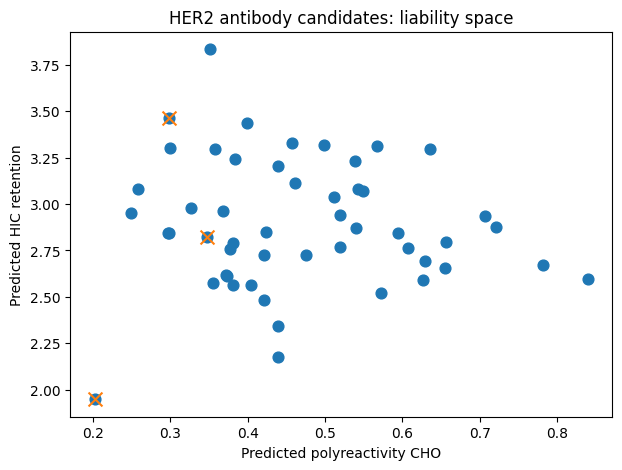

,rank,design_id,vh_sequence,vl_sequence,developability_score,is_pareto,pred_polyreactivity_cho,pred_hic_retention,pred_acsins_pH7p4
0,1,her2_vh_vl_complex_seq23,EVTLTETPTSTEVTEGDSVTVTCTASAPVSGNVQWYKQKPGGPLQL...,SLSLTVSGGGTIAAGASTTLTCTVSGVDFLQYRVAWVAQKPGGPLQ...,5.774236,True,0.202151,1.948827,-46.673607
1,2,her2_vh_vl_complex_seq18,AVTLTETPSSLEVKEGDSVTVTCTASQDVSGGWQWYKQKPGGPLEL...,GVSLTFSGAGTIAPGASFTLTCTVSGVDFLQYDVAWVMQKPGGPLQ...,2.890588,True,0.347627,2.820611,-52.143593
2,3,her2_vh_vl_complex_seq42,KVTITETPSALEVEEGDAVTITCTFSEDVSGKVAWYKQKPGGPLQL...,SLSLSVSGGGVIPPGASTTLTCTVSGVDFNQYRIAWVRQKPGGPLE...,2.864079,False,0.439806,2.178228,-41.712002
3,4,her2_vh_vl_complex_seq25,AVTLTETPTSTSVTLGDSVTVTCTASADVSGGVQWYRQKPGGPFEA...,GPSLTVSGGGTIAAGASTTFTCTVSGLDFLQYEVAWVRQKPGGPFQ...,2.418335,False,0.381414,2.563267,-43.868866
4,5,her2_vh_vl_complex_seq17,SVTLTETPSSTSATLGDSLTVTCTASSDVSGDVQWYKQLPGGPLQL...,GVSLSFSGGGVIKPGESTTFTCTVSGVDFLTYRVAWVRQLPGGPLQ...,2.338440,False,0.249252,2.954512,-44.902573
5,6,her2_vh_vl_complex_seq10,SVTLTETPSALEATDGETVTITCTASEDVSGQVQWYRQKPGGPLEL...,SLTLTVSGAGVIKSGESFTLTCTVSGVDFLQYKVAWVTQKPGGPLQ...,2.276599,False,0.404504,2.565541,-44.092766
6,7,her2_vh_vl_complex_seq28,KVTLTETPASTAAEEGTSLTVTCTASEDVSGGVQWYAQKPGGPLEL...,GVSLTVSGGGTIKAGESQTLTCTVSGVDFLQYRVAWVRQKPGGPLE...,2.044100,False,0.371535,2.615444,-41.386845
7,8,her2_vh_vl_complex_seq6,AVTITMTPSSTAVEEGTSLTVTCTASKDVSGDVQWYKQKPGGPLTA...,GVSLTVSGGGTIAPGASTTLTCTVSGVDFLQYRVGWVRQKPGGPLE...,1.997225,False,0.421028,2.727991,-46.669327
8,9,her2_vh_vl_complex_seq38,SVTLTETPSSLEAELGDSVTVTCTLSSDVSSGVQWYKQKPGGPLEL...,GLSLTVSGAGTIAAGASTTLTCTVSGLDFLQYRVAWVLQKPGGPFQ...,1.890582,False,0.296602,2.843487,-41.208057
9,10,her2_vh_vl_complex_seq21,SVTWTETPSSTEVTEGDSITITCTASEDVSGGVQWYKQKPGGPLQA...,PVSLTFSGAGTIKPGESTTLTCTVSGLDFLQYRVGWVRQKPGGPFE...,1.868391,False,0.376889,2.757992,-43.693649


In [ ]:
# ============================================================
# 15. Plot candidate ranking
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(
    cand_df["pred_polyreactivity_cho"],
    cand_df["pred_hic_retention"],
    s=60,
)

pareto_df = cand_df[cand_df["is_pareto"]]

plt.scatter(
    pareto_df["pred_polyreactivity_cho"],
    pareto_df["pred_hic_retention"],
    s=100,
    marker="x",
)

plt.xlabel("Predicted polyreactivity CHO")
plt.ylabel("Predicted HIC retention")
plt.title("HER2 antibody candidates: liability space")
plt.show()

# ============================================================
# 16. Export top candidates
# ============================================================

TOP_N = 10

top_df = cand_df.head(TOP_N)

TOP_OUT = os.path.join(OUT_DIR, "top_her2_candidates.csv")
top_df.to_csv(TOP_OUT, index=False)

top_df[
    [
        "rank",
        "design_id",
        "vh_sequence",
        "vl_sequence",
        "developability_score",
        "is_pareto",
        "pred_polyreactivity_cho",
        "pred_hic_retention",
        "pred_acsins_pH7p4",
    ]
]

In [ ]:
# ============================================================
# Dry-lab sequence liability scoring for HER2 antibody candidates
# ============================================================

!pip -q install biopython

import re
import numpy as np
import pandas as pd
from Bio.SeqUtils.ProtParam import ProteinAnalysis

AA_SET = set("ACDEFGHIKLMNPQRSTVWY")

def clean_seq(seq):
    if pd.isna(seq):
        return ""
    seq = str(seq).upper().strip()
    return "".join([aa for aa in seq if aa in AA_SET])


# -----------------------------
# Basic sequence features
# -----------------------------

def count_nglyc_motifs(seq):
    """
    N-linked glycosylation motif:
    N-X-S/T where X != P
    """
    return len(re.findall(r"N[^P][ST]", seq))


def count_extra_cys(seq):
    """
    Crude cysteine liability.
    Antibody domains usually have conserved cysteines.
    Extra cysteines may create pairing issues.
    """
    return max(seq.count("C") - 2, 0)


def aromatic_fraction(seq):
    if len(seq) == 0:
        return np.nan
    return sum(seq.count(aa) for aa in "FWY") / len(seq)


def hydrophobic_fraction(seq):
    if len(seq) == 0:
        return np.nan
    return sum(seq.count(aa) for aa in "AILMFWVY") / len(seq)


def charged_fraction(seq):
    if len(seq) == 0:
        return np.nan
    return sum(seq.count(aa) for aa in "DEKRH") / len(seq)


def net_charge(seq, ph=7.4):
    if len(seq) == 0:
        return np.nan
    try:
        return ProteinAnalysis(seq).charge_at_pH(ph)
    except Exception:
        return np.nan


def gravy(seq):
    if len(seq) == 0:
        return np.nan
    try:
        return ProteinAnalysis(seq).gravy()
    except Exception:
        return np.nan


def instability_index(seq):
    if len(seq) == 0:
        return np.nan
    try:
        return ProteinAnalysis(seq).instability_index()
    except Exception:
        return np.nan


def molecular_weight(seq):
    if len(seq) == 0:
        return np.nan
    try:
        return ProteinAnalysis(seq).molecular_weight()
    except Exception:
        return np.nan


# -----------------------------
# Crude CDR-like region extraction
# -----------------------------
# This is NOT IMGT/ANARCI numbering.
# It is only a rough proxy for quick MVP liability scoring.

def crude_cdr_windows(seq, chain_type="H"):
    """
    Approximate antibody variable-domain CDR windows.
    Assumes standard VH/VL length around 100-130 aa.
    """
    L = len(seq)

    if chain_type == "H":
        windows = {
            "cdr1": seq[25:min(35, L)],
            "cdr2": seq[50:min(65, L)],
            "cdr3": seq[95:min(115, L)],
        }
    else:
        windows = {
            "cdr1": seq[23:min(35, L)],
            "cdr2": seq[49:min(57, L)],
            "cdr3": seq[88:min(105, L)],
        }

    return windows


def cdr_hydrophobicity(seq, chain_type="H"):
    windows = crude_cdr_windows(seq, chain_type)
    cdr_seq = "".join(windows.values())
    return hydrophobic_fraction(cdr_seq)


def cdr_charge(seq, chain_type="H"):
    windows = crude_cdr_windows(seq, chain_type)
    cdr_seq = "".join(windows.values())
    return net_charge(cdr_seq)


def cdr_aromatic_fraction(seq, chain_type="H"):
    windows = crude_cdr_windows(seq, chain_type)
    cdr_seq = "".join(windows.values())
    return aromatic_fraction(cdr_seq)


def cdr_total_length(seq, chain_type="H"):
    windows = crude_cdr_windows(seq, chain_type)
    return sum(len(v) for v in windows.values())


# -----------------------------
# Candidate scoring
# -----------------------------

def score_antibody_pair(vh, vl):
    vh = clean_seq(vh)
    vl = clean_seq(vl)
    pair = vh + vl

    return {
        "vh_len": len(vh),
        "vl_len": len(vl),
        "pair_len": len(pair),

        "vh_net_charge_pH7p4": net_charge(vh),
        "vl_net_charge_pH7p4": net_charge(vl),
        "pair_net_charge_pH7p4": net_charge(pair),

        "vh_gravy": gravy(vh),
        "vl_gravy": gravy(vl),
        "pair_gravy": gravy(pair),

        "vh_instability_index": instability_index(vh),
        "vl_instability_index": instability_index(vl),
        "pair_instability_index": instability_index(pair),

        "vh_mw": molecular_weight(vh),
        "vl_mw": molecular_weight(vl),

        "vh_nglyc_motifs": count_nglyc_motifs(vh),
        "vl_nglyc_motifs": count_nglyc_motifs(vl),
        "pair_nglyc_motifs": count_nglyc_motifs(pair),

        "vh_extra_cys": count_extra_cys(vh),
        "vl_extra_cys": count_extra_cys(vl),
        "pair_extra_cys": count_extra_cys(pair),

        "vh_hydrophobic_frac": hydrophobic_fraction(vh),
        "vl_hydrophobic_frac": hydrophobic_fraction(vl),
        "pair_hydrophobic_frac": hydrophobic_fraction(pair),

        "vh_aromatic_frac": aromatic_fraction(vh),
        "vl_aromatic_frac": aromatic_fraction(vl),
        "pair_aromatic_frac": aromatic_fraction(pair),

        "vh_charged_frac": charged_fraction(vh),
        "vl_charged_frac": charged_fraction(vl),
        "pair_charged_frac": charged_fraction(pair),

        "cdrh_total_len_proxy": cdr_total_length(vh, "H"),
        "cdrl_total_len_proxy": cdr_total_length(vl, "L"),
        "cdrh_hydrophobicity_proxy": cdr_hydrophobicity(vh, "H"),
        "cdrl_hydrophobicity_proxy": cdr_hydrophobicity(vl, "L"),
        "cdrh_charge_proxy": cdr_charge(vh, "H"),
        "cdrl_charge_proxy": cdr_charge(vl, "L"),
        "cdrh_aromatic_frac_proxy": cdr_aromatic_fraction(vh, "H"),
        "cdrl_aromatic_frac_proxy": cdr_aromatic_fraction(vl, "L"),
    }


dry_rows = []

for _, row in cand_df.iterrows():
    scores = score_antibody_pair(row["vh_sequence"], row["vl_sequence"])
    dry_rows.append(scores)

dry_df = pd.DataFrame(dry_rows)

cand_scored = pd.concat(
    [cand_df.reset_index(drop=True), dry_df.reset_index(drop=True)],
    axis=1
)

cand_scored.head()

FINAL_OUT = "/content/drive/MyDrive/gdpa1_simple_benchmark/her2_candidates_final_drylab_scored.csv"

import os
os.makedirs(os.path.dirname(FINAL_OUT), exist_ok=True)

cand_scored.to_csv(FINAL_OUT, index=False)

print("Saved:", FINAL_OUT)

Saved: /content/drive/MyDrive/gdpa1_simple_benchmark/her2_candidates_final_drylab_scored.csv


In [ ]:
# ============================================================
# Composite dry-lab liability score
# Lower liability_score = better
# ============================================================

liability_cols = [
    "pair_nglyc_motifs",
    "pair_extra_cys",
    "pair_gravy",
    "pair_instability_index",
    "pair_hydrophobic_frac",
    "pair_aromatic_frac",
    "cdrh_hydrophobicity_proxy",
    "cdrl_hydrophobicity_proxy",
]

def zscore(s):
    s = s.astype(float)
    if s.std() == 0 or np.isnan(s.std()):
        return s * 0
    return (s - s.mean()) / s.std()

for col in liability_cols:
    cand_scored[f"z_{col}"] = zscore(cand_scored[col])

cand_scored["dry_lab_liability_score"] = cand_scored[
    [f"z_{c}" for c in liability_cols]
].sum(axis=1)

cand_scored["dry_lab_score"] = -cand_scored["dry_lab_liability_score"]

cand_scored = cand_scored.sort_values(
    "dry_lab_score",
    ascending=False
).reset_index(drop=True)

cand_scored[
    [
        "design_id",
        "dry_lab_score",
        "dry_lab_liability_score",
        "pair_nglyc_motifs",
        "pair_extra_cys",
        "pair_gravy",
        "pair_instability_index",
        "cdrh_hydrophobicity_proxy",
        "cdrl_hydrophobicity_proxy",
    ]
].head(20)

,design_id,dry_lab_score,dry_lab_liability_score,pair_nglyc_motifs,pair_extra_cys,pair_gravy,pair_instability_index,cdrh_hydrophobicity_proxy,cdrl_hydrophobicity_proxy
0,her2_vh_vl_complex_seq31,5.835584,-5.835584,4,10,-0.149312,25.699541,0.288889,0.405405
1,her2_vh_vl_complex_seq44,5.752004,-5.752004,2,10,-0.160321,33.297729,0.288889,0.378378
2,her2_vh_vl_complex_seq24,5.484847,-5.484847,1,10,-0.258716,27.040849,0.311111,0.432432
3,her2_vh_vl_complex_seq30,4.985672,-4.985672,4,10,-0.157110,25.345183,0.288889,0.378378
4,her2_vh_vl_complex_seq43,4.154509,-4.154509,2,10,-0.270413,34.289243,0.288889,0.405405
5,her2_vh_vl_complex_seq13,4.151921,-4.151921,1,10,-0.207798,34.083739,0.311111,0.432432
6,her2_vh_vl_complex_seq32,3.557700,-3.557700,1,10,-0.176376,27.638555,0.333333,0.378378
7,her2_vh_vl_complex_seq41,3.330059,-3.330059,4,11,-0.211468,31.126858,0.288889,0.405405
8,her2_vh_vl_complex_seq10,3.234915,-3.234915,4,10,-0.171101,22.052317,0.333333,0.405405
9,her2_vh_vl_complex_seq42,2.947522,-2.947522,4,12,-0.261697,24.783280,0.355556,0.378378


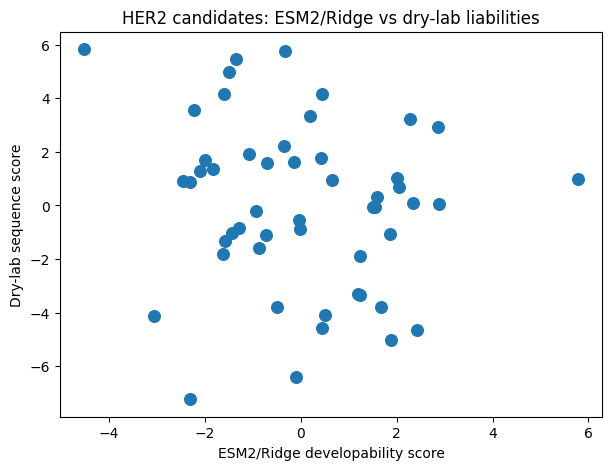

In [ ]:
# ============================================================
# Final combined score
# Higher = better
# ============================================================

cand_scored["z_developability_score"] = zscore(cand_scored["developability_score"])
cand_scored["z_dry_lab_score"] = zscore(cand_scored["dry_lab_score"])

cand_scored["final_combined_score"] = (
    cand_scored["z_developability_score"] +
    cand_scored["z_dry_lab_score"]
)

cand_scored = cand_scored.sort_values(
    "final_combined_score",
    ascending=False
).reset_index(drop=True)

cand_scored["final_rank"] = np.arange(1, len(cand_scored) + 1)

cand_scored[
    [
        "final_rank",
        "design_id",
        "final_combined_score",
        "developability_score",
        "dry_lab_score",
        "pred_polyreactivity_cho",
        "pred_hic_retention",
        "pred_acsins_pH7p4",
        "pair_nglyc_motifs",
        "pair_extra_cys",
        "pair_gravy",
        "pair_instability_index",
    ]
].head(20)

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(
    cand_scored["developability_score"],
    cand_scored["dry_lab_score"],
    s=70
)

plt.xlabel("ESM2/Ridge developability score")
plt.ylabel("Dry-lab sequence score")
plt.title("HER2 candidates: ESM2/Ridge vs dry-lab liabilities")
plt.show()

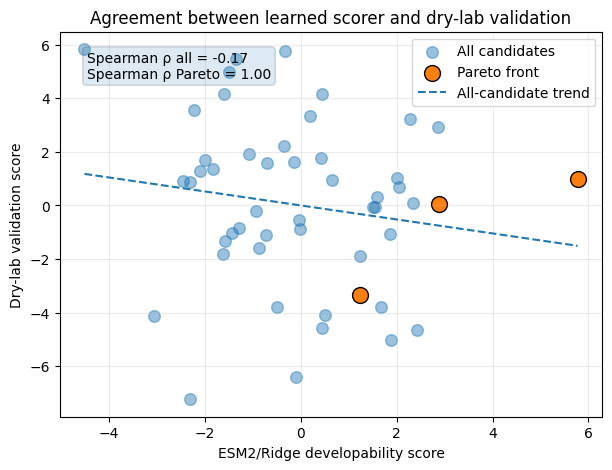

In [ ]:
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Make sure Pareto flag exists in cand_scored
# ------------------------------------------------------------

if "is_pareto" not in cand_scored.columns:
    liability_cols = [
        "pred_polyreactivity_cho",
        "pred_hic_retention",
        "pred_acsins_pH7p4",
    ]

    def get_pareto_front_minimize(values):
        n = values.shape[0]
        is_pareto = np.ones(n, dtype=bool)

        for i in range(n):
            dominated = np.any(
                np.all(values <= values[i], axis=1) &
                np.any(values < values[i], axis=1)
            )
            if dominated:
                is_pareto[i] = False

        return is_pareto

    cand_scored["is_pareto"] = get_pareto_front_minimize(
        cand_scored[liability_cols].values
    )


# ------------------------------------------------------------
# Correlation helper
# ------------------------------------------------------------

def corr_summary(df, x_col, y_col, label):
    tmp = df[[x_col, y_col]].dropna()

    if len(tmp) < 3:
        return {
            "group": label,
            "n": len(tmp),
            "pearson_r": np.nan,
            "pearson_p": np.nan,
            "spearman_rho": np.nan,
            "spearman_p": np.nan,
        }

    pr, pp = pearsonr(tmp[x_col], tmp[y_col])
    sr, sp = spearmanr(tmp[x_col], tmp[y_col])

    return {
        "group": label,
        "n": len(tmp),
        "pearson_r": pr,
        "pearson_p": pp,
        "spearman_rho": sr,
        "spearman_p": sp,
    }


corr_df = pd.DataFrame([
    corr_summary(
        cand_scored,
        "developability_score",
        "dry_lab_score",
        "all_candidates"
    ),
    corr_summary(
        cand_scored[cand_scored["is_pareto"]],
        "developability_score",
        "dry_lab_score",
        "pareto_front"
    )
])

corr_df

# ------------------------------------------------------------
# Scatter: ESM2/Ridge score vs dry-lab score
# ------------------------------------------------------------

all_df = cand_scored.copy()
pareto_df = cand_scored[cand_scored["is_pareto"]].copy()

plt.figure(figsize=(7, 5))

plt.scatter(
    all_df["developability_score"],
    all_df["dry_lab_score"],
    s=70,
    alpha=0.45,
    label="All candidates",
)

plt.scatter(
    pareto_df["developability_score"],
    pareto_df["dry_lab_score"],
    s=130,
    edgecolors="black",
    label="Pareto front",
)

# Regression line for all candidates
x = all_df["developability_score"].values
y = all_df["dry_lab_score"].values
mask = ~np.isnan(x) & ~np.isnan(y)

if mask.sum() >= 2:
    m, b = np.polyfit(x[mask], y[mask], 1)
    x_line = np.linspace(x[mask].min(), x[mask].max(), 100)
    y_line = m * x_line + b
    plt.plot(x_line, y_line, linestyle="--", label="All-candidate trend")

# Add correlation text
r_all = corr_df.loc[corr_df["group"] == "all_candidates", "spearman_rho"].values[0]
r_par = corr_df.loc[corr_df["group"] == "pareto_front", "spearman_rho"].values[0]

plt.text(
    0.05,
    0.95,
    f"Spearman ρ all = {r_all:.2f}\nSpearman ρ Pareto = {r_par:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.15),
)

plt.xlabel("ESM2/Ridge developability score")
plt.ylabel("Dry-lab validation score")
plt.title("Agreement between learned scorer and dry-lab validation")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [ ]:
!pip -q install biopython torch pandas numpy scikit-learn tqdm
import os, glob, math
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from Bio.PDB import PDBParser

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# Folder containing RFdiffusion-generated PDBs
RFD_PDB_DIR = "/content/her2_rfdiffusion_mvp/rfdiffusion_outputs"

# Candidate table after ProteinMPNN + ESM2/Ridge + dry-lab scoring
# Must contain: backbone_id, developability_score, dry_lab_score
SCORED_CSV = "/content/drive/MyDrive/gdpa1_simple_benchmark/her2_candidates_final_drylab_scored.csv"

OUT_DIR = "/content/drive/MyDrive/gdpa1_simple_benchmark/guidance_student"
os.makedirs(OUT_DIR, exist_ok=True)

MAX_LEN = 160     # binder C-alpha length; pad/truncate
BINDER_CHAIN = "B"
TARGET_CHAIN = "A"

DEVICE: cuda


In [ ]:
cand_scored = pd.read_csv(SCORED_CSV)

import numpy as np

def zscore(x):
    x = np.asarray(x, dtype=float)
    sd = np.nanstd(x)
    if sd == 0 or np.isnan(sd):
        return np.zeros_like(x)
    return (x - np.nanmean(x)) / sd

# Use ONLY developability score
cand_scored["z_developability_score"] = zscore(cand_scored["developability_score"])

cand_scored["teacher_score"] = cand_scored["z_developability_score"]

backbone_labels = (
    cand_scored
    .groupby("backbone_id")
    .agg(
        teacher_score=("teacher_score", "max"),  # best sequence per backbone
        mean_teacher_score=("teacher_score", "mean"),
        n_seq=("teacher_score", "count"),
    )
    .reset_index()
)

backbone_labels.head()

,backbone_id,teacher_score,mean_teacher_score,n_seq
0,her2_vh_vl_complex,3.07035,2.612289e-17,51


In [ ]:
def get_ca_coords(pdb_path, chain_id):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("x", pdb_path)

    coords = []

    for model in structure:
        for chain in model:
            if chain.id != chain_id:
                continue
            for res in chain:
                if res.id[0] == " " and "CA" in res:
                    coords.append(res["CA"].coord)

    if len(coords) == 0:
        return None

    return np.asarray(coords, dtype=np.float32)


def pad_or_truncate(coords, max_len=160):
    """
    coords: [L, 3]
    returns:
      coords_pad: [max_len, 3]
      mask: [max_len]
    """
    L = len(coords)

    if L >= max_len:
        coords = coords[:max_len]
        mask = np.ones(max_len, dtype=np.float32)
    else:
        pad = np.zeros((max_len - L, 3), dtype=np.float32)
        coords = np.vstack([coords, pad])
        mask = np.zeros(max_len, dtype=np.float32)
        mask[:L] = 1.0

    return coords.astype(np.float32), mask.astype(np.float32)


def normalize_coords(coords, mask):
    """
    Center coordinates by valid residues.
    """
    valid = mask > 0
    if valid.sum() == 0:
        return coords

    center = coords[valid].mean(axis=0, keepdims=True)
    coords = coords - center
    coords[~valid] = 0.0

    return coords.astype(np.float32)

In [ ]:
%cd /content

!git clone https://github.com/RosettaCommons/RFdiffusion.git || true
%cd /content/RFdiffusion

!pip -q install hydra-core pyrsistent icecream einops biopython

%cd /content/RFdiffusion

!mkdir -p models

!wget -q http://files.ipd.uw.edu/pub/RFdiffusion/6f5902ac237024bdd0c176cb93063dc4/Base_ckpt.pt \
  -O models/Base_ckpt.pt

!wget -q http://files.ipd.uw.edu/pub/RFdiffusion/6f5902ac237024bdd0c176cb93063dc4/Complex_base_ckpt.pt \
  -O models/Complex_base_ckpt.pt

!ls -lh models

from Bio.PDB import PDBParser, PDBIO, Select
import os

HER2_DIR = f"{BASE}/her2"
RFD_OUT = f"{BASE}/rfdiffusion_outputs"

os.makedirs(HER2_DIR, exist_ok=True)
os.makedirs(RFD_OUT, exist_ok=True)

# Use HER2-antibody complex
!wget -q https://files.rcsb.org/download/6OGE.pdb -O /content/6OGE.pdb

INPUT_PDB = "/content/6OGE.pdb"
HER2_CHAIN = "A"
HER2_TARGET_PDB = f"{HER2_DIR}/her2_target_chain_A.pdb"

class ChainSelect(Select):
    def __init__(self, chain_id):
        self.chain_id = chain_id
    def accept_chain(self, chain):
        return chain.id == self.chain_id

parser = PDBParser(QUIET=True)
structure = parser.get_structure("her2", INPUT_PDB)

io = PDBIO()
io.set_structure(structure)
io.save(HER2_TARGET_PDB, ChainSelect(HER2_CHAIN))

print("Saved:", HER2_TARGET_PDB)

/content
Cloning into 'RFdiffusion'...
remote: Enumerating objects: 753, done.
remote: Counting objects: 100% (546/546), done.
remote: Compressing objects: 100% (340/340), done.
remote: Total 753 (delta 337), reused 236 (delta 202), pack-reused 207 (from 1)
Receiving objects: 100% (753/753), 10.19 MiB | 15.95 MiB/s, done.
Resolving deltas: 100% (385/385), done.
/content/RFdiffusion
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.3/122.3 kB 14.2 MB/s eta 0:00:00
/content/RFdiffusion
total 462M
-rw-r--r-- 1 root root 462M Mar 30  2023 Base_ckpt.pt
-rw-r--r-- 1 root root    0 Apr 29 02:04 Complex_base_ckpt.pt
Saved: /content/drive/MyDrive/her2_ab_mvp/her2/her2_target_chain_A.pdb


In [ ]:
%cd /content/RFdiffusion

import os
os.environ["PYTHONPATH"] = "/content/RFdiffusion:" + os.environ.get("PYTHONPATH", "")

!echo $PYTHONPATH
!python -c "import rfdiffusion; print('rfdiffusion import OK')"

/content/RFdiffusion
/content/RFdiffusion:/env/python
rfdiffusion import OK


In [ ]:
HER2_CLEAN_PDB = f"{HER2_DIR}/her2_target_clean.pdb"

with open(HER2_TARGET_PDB) as f, open(HER2_CLEAN_PDB, "w") as g:
    for line in f:
        if line.startswith("ATOM"):
            g.write(line)
    g.write("END\n")

print("Clean target:", HER2_CLEAN_PDB)

from Bio.PDB import PDBParser

parser = PDBParser(QUIET=True)
structure = parser.get_structure("her2", HER2_CLEAN_PDB)

res_ids = []

for model in structure:
    for chain in model:
        for res in chain:
            if res.id[0] == " ":
                res_ids.append(res.id[1])

print("Min residue:", min(res_ids))
print("Max residue:", max(res_ids))
print("N residues:", len(set(res_ids)))

%cd /content/RFdiffusion

!PYTHONPATH=/content/RFdiffusion python /content/RFdiffusion/scripts/run_inference.py \
  inference.ckpt_override_path=/content/RFdiffusion/models/Complex_base_ckpt.pt \
  inference.input_pdb={HER2_CLEAN_PDB} \
  inference.output_prefix={RFD_OUT}/her2_binder \
  inference.num_designs=20 \
  'contigmap.contigs=[A1-619/0 100-130]' \
  'ppi.hotspot_res=[A557,A558,A561,A570]'

import glob, os

all_pdbs = glob.glob(f"{RFD_OUT}/**/*.pdb", recursive=True)

print("Found RFdiffusion PDBs:", len(all_pdbs))
print(all_pdbs[:5])

Clean target: /content/drive/MyDrive/her2_ab_mvp/her2/her2_target_clean.pdb
Min residue: 23
Max residue: 644
N residues: 619
/content/RFdiffusion
/content/RFdiffusion/scripts/run_inference.py:63: SyntaxWarning: invalid escape sequence '\d'
  m = re.match(".*_(\d+)\.pdb$", e)
/content/RFdiffusion/rfdiffusion/util.py:253: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp:63.)
  Z = torch.cross(Xn, Yn)
/content/RFdiffusion/rfdiffusion/diffusion.py:267: SyntaxWarning: invalid escape sequence '\s'
  Extract \sigma(t) corresponding to chosen sigma schedule.
/content/RFdiffusion/rfdiffusion/diffusion.py:294: SyntaxWarning: invalid escape sequence '\i'
  sigma(t)^2 := \int_0^t g(s)^2 ds,
Traceback (most recent call last):
  File "/content/RF

In [ ]:
all_pdbs = glob.glob(f"{RFD_PDB_DIR}/**/*.pdb", recursive=True)

print("Found PDBs:", len(all_pdbs))
print(all_pdbs[:5])

def find_pdb_for_backbone(backbone_id, all_pdbs):
    """
    Flexible matching because RFdiffusion/ProteinMPNN filenames often differ.
    """
    backbone_id = str(backbone_id)

    candidates = []
    for p in all_pdbs:
        base = os.path.basename(p).replace(".pdb", "")
        if backbone_id == base or backbone_id in base or base in backbone_id:
            candidates.append(p)

    if len(candidates) == 0:
        return None

    return candidates[0]


rows = []

for _, row in backbone_labels.iterrows():
    backbone_id = row["backbone_id"]
    pdb_path = find_pdb_for_backbone(backbone_id, all_pdbs)

    if pdb_path is None:
        print("Missing PDB for:", backbone_id)
        continue

    rows.append({
        "backbone_id": backbone_id,
        "pdb_path": pdb_path,
        "teacher_score": row["teacher_score"],
        "n_seq": row["n_seq"],
    })

student_df = pd.DataFrame(rows)
print(student_df.shape)
student_df.head()

Found PDBs: 0
[]
Missing PDB for: her2_vh_vl_complex
(0, 0)


""


In [ ]:
class BackboneScoreDataset(Dataset):
    def __init__(self, df, max_len=160, binder_chain="B"):
        self.df = df.reset_index(drop=True)
        self.max_len = max_len
        self.binder_chain = binder_chain

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        coords = get_ca_coords(row["pdb_path"], self.binder_chain)

        if coords is None:
            raise ValueError(f"No coords found: {row['pdb_path']}")

        coords, mask = pad_or_truncate(coords, self.max_len)
        coords = normalize_coords(coords, mask)

        y = np.float32(row["teacher_score"])

        return {
            "coords": torch.tensor(coords, dtype=torch.float32),
            "mask": torch.tensor(mask, dtype=torch.float32),
            "y": torch.tensor(y, dtype=torch.float32),
            "backbone_id": row["backbone_id"],
        }

In [ ]:
class DistanceMapStudent(nn.Module):
    def __init__(self, max_len=160):
        super().__init__()
        self.max_len = max_len

        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((4, 4)),
        )

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 1),
        )

    def forward(self, coords, mask=None):
        """
        coords: [B, L, 3]
        mask: [B, L]
        """
        diff = coords[:, :, None, :] - coords[:, None, :, :]
        dmap = torch.sqrt((diff ** 2).sum(dim=-1) + 1e-8)

        if mask is not None:
            pair_mask = mask[:, :, None] * mask[:, None, :]
            dmap = dmap * pair_mask

        # normalize distances roughly
        dmap = dmap / 20.0

        x = dmap.unsqueeze(1)  # [B, 1, L, L]
        h = self.conv(x)
        out = self.head(h).squeeze(-1)

        return out

In [ ]:
dataset = BackboneScoreDataset(
    student_df,
    max_len=MAX_LEN,
    binder_chain=BINDER_CHAIN,
)

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
)

student = DistanceMapStudent(max_len=MAX_LEN).to(DEVICE)
opt = torch.optim.AdamW(student.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS = 100

loss_history = []

for epoch in range(EPOCHS):
    student.train()
    losses = []

    for batch in loader:
        coords = batch["coords"].to(DEVICE)
        mask = batch["mask"].to(DEVICE)
        y = batch["y"].to(DEVICE)

        pred = student(coords, mask)
        loss = F.mse_loss(pred, y)

        opt.zero_grad()
        loss.backward()
        opt.step()

        losses.append(loss.item())

    mean_loss = np.mean(losses)
    loss_history.append(mean_loss)

    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        print(f"epoch {epoch:03d} | loss {mean_loss:.4f}")

In [ ]:
MODEL_PATH = os.path.join(OUT_DIR, "distance_map_student.pt")

torch.save({
    "model_state_dict": student.state_dict(),
    "max_len": MAX_LEN,
    "binder_chain": BINDER_CHAIN,
}, MODEL_PATH)

print("Saved:", MODEL_PATH)

In [ ]:
student.eval()

pred_rows = []

with torch.no_grad():
    for batch in DataLoader(dataset, batch_size=8, shuffle=False):
        coords = batch["coords"].to(DEVICE)
        mask = batch["mask"].to(DEVICE)

        pred = student(coords, mask).detach().cpu().numpy()

        for backbone_id, p, y in zip(batch["backbone_id"], pred, batch["y"].numpy()):
            pred_rows.append({
                "backbone_id": backbone_id,
                "teacher_score": float(y),
                "student_pred_score": float(p),
            })

pred_df = pd.DataFrame(pred_rows)
pred_df.head()

import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

if len(pred_df) >= 3:
    sp = spearmanr(pred_df["teacher_score"], pred_df["student_pred_score"]).statistic
    pr = pearsonr(pred_df["teacher_score"], pred_df["student_pred_score"])[0]
else:
    sp, pr = np.nan, np.nan

plt.figure(figsize=(5, 5))
plt.scatter(pred_df["teacher_score"], pred_df["student_pred_score"], s=70)
plt.xlabel("Teacher score")
plt.ylabel("Student predicted score")
plt.title(f"Structure-student fit\nSpearman={sp:.2f}, Pearson={pr:.2f}")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
def student_guidance_update(
    coords,
    mask,
    student,
    guidance_scale=0.05,
    normalize_grad=True,
):
    """
    coords: torch tensor [B, L, 3], differentiable noisy/current coords
    mask: torch tensor [B, L]
    returns guided coords

    This performs:
      coords <- coords + scale * grad(student_score wrt coords)
    """

    student.eval()

    coords = coords.detach().clone().requires_grad_(True)
    mask = mask.detach()

    score = student(coords, mask).sum()

    grad = torch.autograd.grad(
        score,
        coords,
        retain_graph=False,
        create_graph=False,
    )[0]

    if normalize_grad:
        grad_norm = torch.sqrt((grad ** 2).sum(dim=(1, 2), keepdim=True) + 1e-8)
        grad = grad / grad_norm

    guided_coords = coords + guidance_scale * grad

    # keep padded residues zero
    guided_coords = guided_coords * mask[:, :, None]

    return guided_coords.detach()

In [ ]:
batch = next(iter(loader))

coords = batch["coords"].to(DEVICE)
mask = batch["mask"].to(DEVICE)

with torch.no_grad():
    before = student(coords, mask).detach().cpu().numpy()

guided_coords = student_guidance_update(
    coords,
    mask,
    student,
    guidance_scale=0.1,
)

with torch.no_grad():
    after = student(guided_coords, mask).detach().cpu().numpy()

pd.DataFrame({
    "before_student_score": before,
    "after_student_score": after,
    "delta": after - before,
}).head()